# Análisis de Campaña de Marketing Bancario
Este análisis examina una campaña de marketing realizada por un banco portugués para promover depósitos a plazo. A través de técnicas avanzadas de análisis de datos y machine learning, identificamos los factores clave que influyen en la decisión del cliente y desarrollamos modelos predictivos para optimizar futuras campañas.

**Objetivos del Análisis:**
- Comprender el comportamiento de los clientes ante ofertas de depósitos
- Identificar segmentos de clientes con mayor probabilidad de conversión
- Desarrollar modelos predictivos para optimizar recursos de marketing
- Proporcionar recomendaciones estratégicas basadas en datos

# Índice de Contenidos

1. [Análisis de Campaña de Marketing Bancario](#análisis-de-campaña-de-marketing-bancario)  
2. [Diccionario de Datos](#diccionario)  
3. [Análisis de Calidad de Datos](#calidad)  
4. [Análisis Exploratorio de Datos (EDA)](#eda)  
    - 4.1 [Variables numéricas](#variables-numéricas)  
      - 4.1.1 [Histogramas](#histogramas)  
      - 4.1.2 [Boxplots](#boxplot)  
      - 4.1.3 [Matriz de correlaciones](#matriz-correlaciones)  
    - 4.2 [Variables categóricas](#variables-categoricas)  
      - 4.2.1 [Gráficos de barras](#graficos-barras)  
      - 4.2.2 [Tablas de frecuencias](#tablas-frecuencias)  
    - 4.3 [Análisis de la Variable Objetivo](#objetivo)  
    - 4.4 [Análisis Bivariado](#bivariado)  
      - 4.4.1 [Variables numéricas](#bivariado-numericas)  
      - 4.4.2 [Variables categóricas](#bivariado-categoricas)  
      - 4.4.3 [Tablas de contingencia](#tablas-contingencia)  
      - 4.4.4 [Patrones temporales](#patrones-temporales)  
    - 4.5 [Hallazgos del Análisis Exploratorio](#hallazgos)  
5. [Modelado Predictivo](#modelado)  
    - 5.1 [Datos preparados](#datos-preparados)  
    - 5.2 [Evaluación de modelos](#evaluación-modelos)  
      - 5.2.1 [Matrices de confusión](#matrices-confusión)  
      - 5.2.2 [Métricas](#metricas)  
      - 5.2.3 [Curvas de respuesta capturada](#curvas-respuesta-capturada)  
      - 5.2.4 [Curvas lift](#curvas-lift)  
      - 5.2.5 [Curvas ROC](#curvas-roc)  
    - 5.3 [Importancia de variables](#importancia-variables)  
      - 5.3.1 [Random Forest](#importancia-random-forest)  
      - 5.3.2 [Regresión logística](#importancia-regresion-logistica)  
6. [Conclusiones Finales](#conclusiones)  


<a id='diccionario'></a>
## Diccionario de Datos

A continuación se presenta la descripción detallada de cada variable del dataset:

<style>
html {
  font-size: 16px !important; 
}

body {
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif;
  font-size: 1.35rem !important; 
  line-height: 1.6;
  color: #333;
  max-width: 90%;
  margin: 0 auto;
  padding: 1rem;
  background: #fff;
}

h1 { 
  font-size: 2.8rem !important; 
  border-bottom: 3px solid #2c3e50;
  padding-bottom: 0.4rem;
  margin-top: 2.5rem;
}
h2 { font-size: 2.2rem !important; } 
h3 { font-size: 1.8rem !important; } 
h4 { font-size: 1.5rem !important; } 
h5 { font-size: 1.3rem !important; } 
h6 { font-size: 1.1rem !important; } 


p {
  margin-bottom: 1.4rem;
  orphans: 3;
  widows: 3;
  font-size: 1.35rem !important; 
}

ul, ol {
  font-size: 1.35rem !important; 
  margin: 0.9rem 0;
  padding-left: 2.2rem;
}

li {
  margin: 0.4rem 0;
  line-height: 1.5;
}

a {
  color: #3498db;
  text-decoration: none;
  font-weight: 500;
  font-size: inherit !important;
}

table {
  font-size: 1.1rem !important;
  width: 100%;
  border-collapse: collapse;
  margin: 2rem 0;
  font-feature-settings: "kern", "liga", "clig";
  text-align: left;
  background-color: #fff;
  box-shadow: 0 1px 6px rgba(0, 0, 0, 0.08);
  border-radius: 6px;
  overflow: hidden;
}

table th {
  background-color: #2c3e50 !important;
  color: white !important;
  padding: 0.7rem 0.9rem;
  font-weight: 500;
  text-transform: uppercase;
  letter-spacing: 0.04em;
  font-size: 0.95em;
  text-align: center !important;
}


@media print {
  body {
    -webkit-print-color-adjust: exact;
    print-color-adjust: exact;
  }
  table, img {
    page-break-inside: avoid;
  }
}


</style>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML, Markdown
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

plt.style.use('seaborn-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

df = pd.read_csv('data/bank_data.csv', sep=';')

diccionario = pd.DataFrame({
    'Variable': ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 
                 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 
                 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 
                 'euribor3m', 'nr.employed', 'y'],
    'Descripción': [
        'Edad del cliente (años)',
        'Tipo de empleo del cliente',
        'Estado civil del cliente',
        'Nivel educativo alcanzado',
        '¿Tiene crédito en mora?',
        '¿Tiene préstamo hipotecario?',
        '¿Tiene préstamo personal?',
        'Medio de contacto utilizado',
        'Mes del último contacto',
        'Día de la semana del contacto',
        'Duración del último contacto (segundos)',
        'Número de contactos en esta campaña',
        'Días desde último contacto de campaña previa',
        'Número de contactos en campañas previas',
        'Resultado de la campaña previa',
        'Tasa de variación del empleo - indicador trimestral',
        'Índice de precios al consumidor - indicador mensual',
        'Índice de confianza del consumidor - indicador mensual',
        'Tipo Euribor a 3 meses - indicador diario',
        'Número de empleados - indicador trimestral',
        '¿Suscribió depósito a plazo? (objetivo)'
    ],
    'Tipo': ['Numérica', 'Categórica', 'Categórica', 'Categórica', 'Categórica', 
             'Categórica', 'Categórica', 'Categórica', 'Categórica', 'Categórica',
             'Numérica', 'Numérica', 'Numérica', 'Numérica', 'Categórica',
             'Numérica', 'Numérica', 'Numérica', 'Numérica', 'Numérica', 'Categórica'],
    'Valores/Rango': ['18-95 años', '12 categorías', '4 categorías', '8 categorías', 
                      'yes/no/unknown', 'yes/no/unknown', 'yes/no/unknown', 
                      'cellular/telephone', '12 meses', '5 días', '0-4918 segundos',
                      '1-56 contactos', '0-999 días', '0-58 contactos', 
                      '3 categorías', '-3.4 - 1.4', '92.2 - 94.8', '-50.8 - -26.9',
                      '0.63 - 5.0', '4963.6 - 5228.1', 'yes/no']
})

display(diccionario.style
        .hide(axis='index')
        .set_properties(**{'text-align': 'center', 'white-space': 'normal'})
        .set_table_styles([
            {'selector': 'td', 'props': [('text-align', 'center'), ('white-space', 'normal'), ('word-wrap', 'break-word')]},
            {'selector': 'th', 'props': [('text-align', 'center')]},
            {'selector': 'table', 'props': [('table-layout', 'auto'), ('width', '100%')]},
            {'selector': 'th.row_heading', 'props': [('text-align', 'center')]}
        ])
        )

Variable,Descripción,Tipo,Valores/Rango
age,Edad del cliente (años),Numérica,18-95 años
job,Tipo de empleo del cliente,Categórica,12 categorías
marital,Estado civil del cliente,Categórica,4 categorías
education,Nivel educativo alcanzado,Categórica,8 categorías
default,¿Tiene crédito en mora?,Categórica,yes/no/unknown
housing,¿Tiene préstamo hipotecario?,Categórica,yes/no/unknown
loan,¿Tiene préstamo personal?,Categórica,yes/no/unknown
contact,Medio de contacto utilizado,Categórica,cellular/telephone
month,Mes del último contacto,Categórica,12 meses
day_of_week,Día de la semana del contacto,Categórica,5 días


<a id='calidad'></a>
## Análisis de Calidad de Datos

Evaluamos la integridad y calidad de nuestros datos antes de proceder con el análisis.

In [2]:

display(Markdown("#### INFORMACIÓN GENERAL DEL DATASET"))

info_df = pd.DataFrame({
    'Métrica': ['Total de registros', 'Total de variables', 'Memoria utilizada (MB)'],
    'Valor': [f"{len(df):,}", len(df.columns), f"{df.memory_usage().sum() / 1024**2:.2f}"]
})

display(info_df.style
        .hide(axis='index')
        .set_properties(**{'text-align': 'center', 'white-space': 'normal'})
        .set_table_styles([
            {'selector': 'td', 'props': [('text-align', 'center'), ('white-space', 'normal'), ('word-wrap', 'break-word')]},
            {'selector': 'th', 'props': [('text-align', 'center')]},
            {'selector': 'table', 'props': [('table-layout', 'auto'), ('width', '100%')]},
            {'selector': 'th.row_heading', 'props': [('text-align', 'center')]}
        ])
        )

display(Markdown("#### ANÁLISIS DE VALORES FALTANTES"))
missing = df.isin(['unknown']).sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Variable': missing[missing > 0].index,
    'Valores Faltantes': missing[missing > 0].values,
    'Porcentaje (%)': missing_pct[missing > 0].values
}).sort_values('Porcentaje (%)', ascending=False)

display(missing_df.style
        .format(precision=2) 
        .hide(axis='index')
        .set_properties(**{'text-align': 'center', 'white-space': 'normal'})
        .set_table_styles([
            {'selector': 'td', 'props': [('text-align', 'center'), ('white-space', 'normal'), ('word-wrap', 'break-word')]},
            {'selector': 'th', 'props': [('text-align', 'center')]},
            {'selector': 'table', 'props': [('table-layout', 'auto'), ('width', '100%')]},
            {'selector': 'th.row_heading', 'props': [('text-align', 'center')]}
        ])
        )

duplicados = df.duplicated().sum()
display(Markdown(f"\nRegistros duplicados: {duplicados}"))

display(Markdown("#### RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS"))
desc_df = df.describe().T
display(desc_df.style
    .format(precision=2) 
    .set_properties(**{
        'text-align': 'center',
        'white-space': 'normal',
        'padding': '8px',
    }) \
    .set_table_styles([
        {
            'selector': 'table',
            'props': [
                ('width', '100%'),
                ('table-layout', 'auto'),
                ('margin', '2rem 0'),
            ]
        },
        {
            'selector': 'th.row_heading',
            'props': [
                ('text-align', 'left'),
                ('white-space', 'normal'),
                ('word-wrap', 'break-word'),
                ('padding', '8px'),
                ('font-weight', '500'),
            ]
        },
        {
            'selector': 'th.col_heading',
            'props': [
                ('text-align', 'center'),
                ('white-space', 'normal'),
                ('padding', '8px'),
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('text-align', 'center'),
                ('white-space', 'normal'),
                ('word-wrap', 'break-word'),
                ('padding', '8px'),
            ]
        },
    ])
        )


#### INFORMACIÓN GENERAL DEL DATASET

Métrica,Valor
Total de registros,"41,188"
Total de variables,21
Memoria utilizada (MB),6.60


#### ANÁLISIS DE VALORES FALTANTES

Variable,Valores Faltantes,Porcentaje (%)
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19



Registros duplicados: 12

#### RESUMEN ESTADÍSTICO DE VARIABLES NUMÉRICAS

,count,mean,std,min,25%,50%,75%,max
age,41188.00,40.02,10.42,17.00,32.00,38.00,47.00,98.00
duration,41188.00,258.29,259.28,0.00,102.00,180.00,319.00,4918.00
campaign,41188.00,2.57,2.77,1.00,1.00,2.00,3.00,56.00
pdays,41188.00,962.48,186.91,0.00,999.00,999.00,999.00,999.00
previous,41188.00,0.17,0.49,0.00,0.00,0.00,0.00,7.00
emp.var.rate,41188.00,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40
cons.price.idx,41188.00,93.58,0.58,92.20,93.08,93.75,93.99,94.77
cons.conf.idx,41188.00,-40.50,4.63,-50.80,-42.70,-41.80,-36.40,-26.90
euribor3m,41188.00,3.62,1.73,0.63,1.34,4.86,4.96,5.04
nr.employed,41188.00,5167.04,72.25,4963.60,5099.10,5191.00,5228.10,5228.10



<a id="matriz-correlaciones"></a>
<div style="page-break-before: always; margin-top: 0;">
    <h1>Análisis Exploratorio de Datos (EDA)</h1>
</div>

Exploramos las características fundamentales de nuestros clientes y patrones de comportamiento.

<a id='variables-numéricas'></a>
## Variables numéricas

<a id='histogramas'></a>
### Histogramas

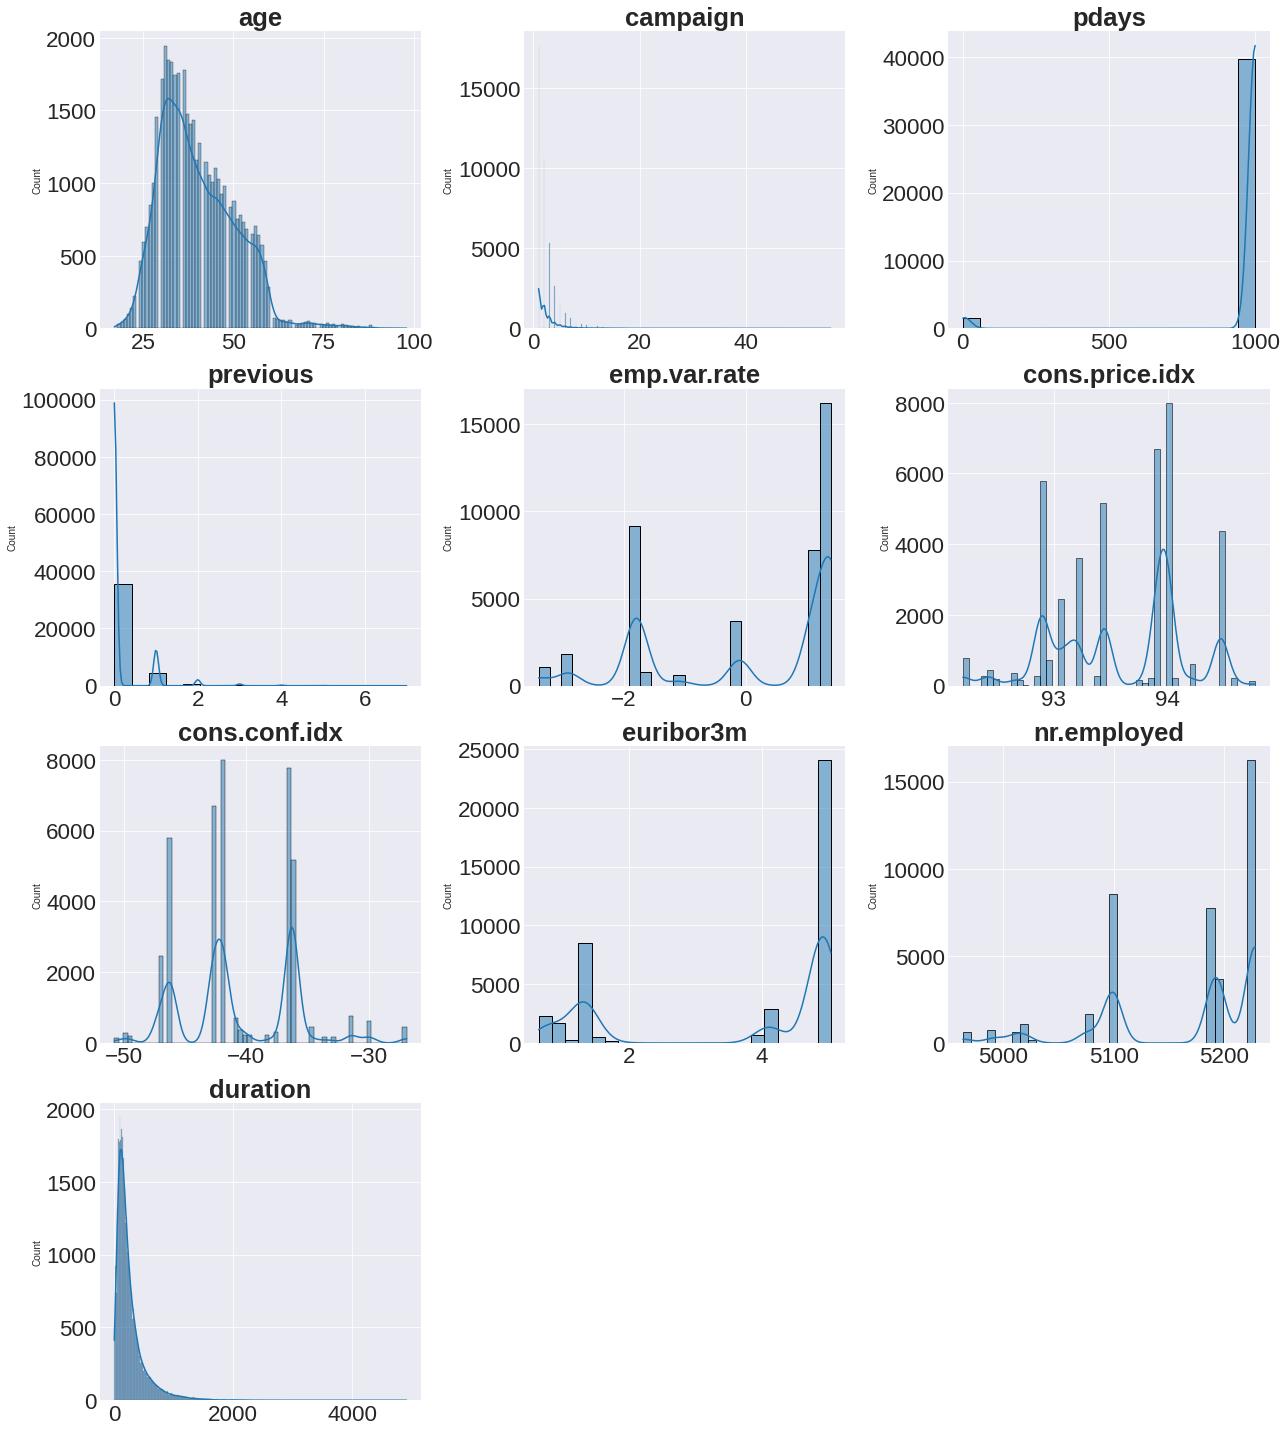

In [3]:
fig, axes = plt.subplots(4, 3, figsize=(18, 20))

numeric_cols = ['age', 'campaign', 'pdays', 'previous',
                'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                'euribor3m', 'nr.employed', 'duration']
axes = axes.ravel()

base_size = 16
title_fontsize = base_size * 1.6   
label_fontsize = base_size * 1.6 
tick_fontsize = base_size * 1.4   
legend_fontsize = base_size * 1.4

for idx, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[idx], color='#1f77b4')
    axes[idx].set_title(f'{col}', fontweight='bold', fontsize=title_fontsize)
    axes[idx].set_xlabel('')
    axes[idx].tick_params(axis='both', which='major', labelsize=tick_fontsize)

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

<a id='boxplot'></a>

<a id="matriz-correlaciones"></a>
<div style="page-break-before: always; margin-top: 0;">
    <h3>Boxplots</h3>
</div>


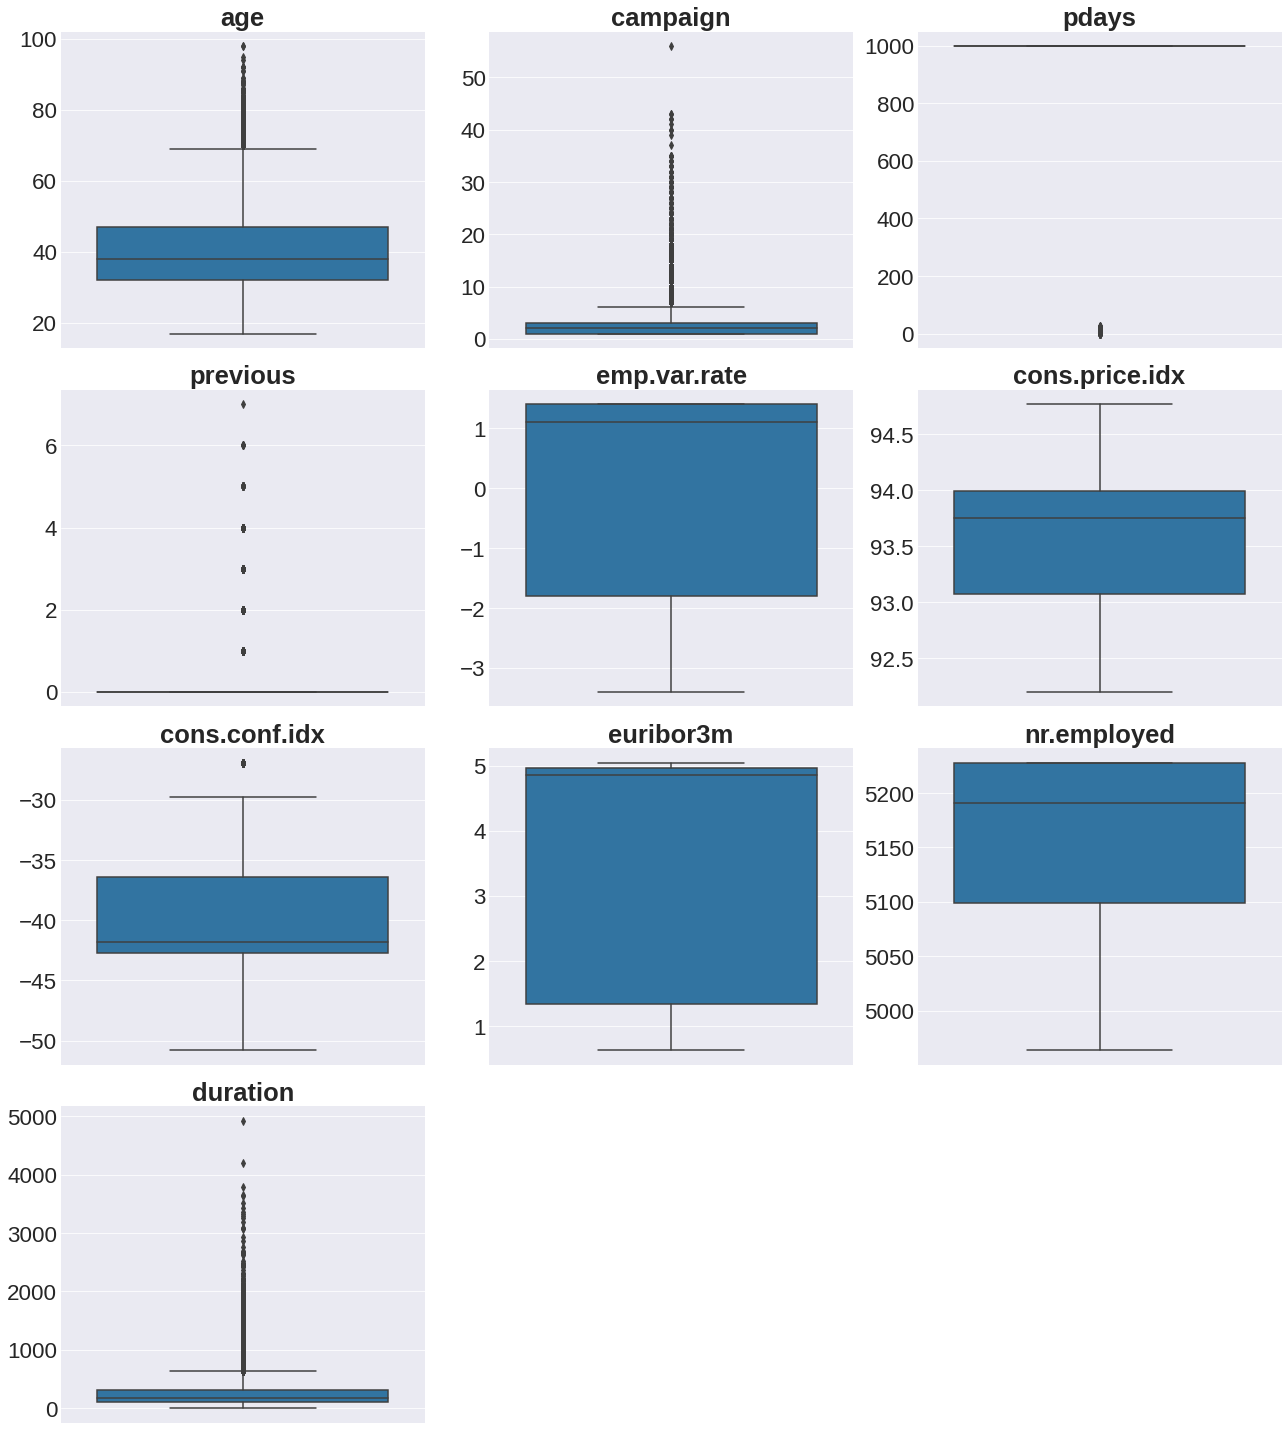

In [4]:
fig, axes = plt.subplots(4, 3, figsize=(18, 20))

axes = axes.ravel()

base_size = 16
title_fontsize = base_size * 1.6   
label_fontsize = base_size * 1.6 
tick_fontsize = base_size * 1.4   
legend_fontsize = base_size * 1.4

for idx, col in enumerate(numeric_cols):
    sns.boxplot(data=df, y=col, ax=axes[idx], color='#1f77b4')
    axes[idx].set_title(f'{col}', fontweight='bold', fontsize=title_fontsize)
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('')
    axes[idx].tick_params(axis='both', which='major', labelsize=tick_fontsize)

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [5]:
outlier_counts = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_counts[col] = len(outliers)

outlier_df = pd.DataFrame(list(outlier_counts.items()), columns=['Variable', 'Outliers'])
outlier_df = outlier_df.sort_values('Outliers', ascending=False)

display(outlier_df.style
        .hide(axis='index')
        .set_properties(**{'text-align': 'center', 'white-space': 'normal'})
        .set_table_styles([
            {'selector': 'td', 'props': [('text-align', 'center'), ('white-space', 'normal'), ('word-wrap', 'break-word')]},
            {'selector': 'th', 'props': [('text-align', 'center')]},
            {'selector': 'table', 'props': [('table-layout', 'auto'), ('width', '100%')]},
            {'selector': 'th.row_heading', 'props': [('text-align', 'center')]}
        ])
        )

Variable,Outliers
previous,5625
duration,2963
campaign,2406
pdays,1515
age,469
cons.conf.idx,447
emp.var.rate,0
cons.price.idx,0
euribor3m,0
nr.employed,0



Los histogramas de variables numéricas revelan distribuciones asimétricas en características clave como duration (tiempo de contacto) y euribor3m (tasa de interés). La variable duration muestra una concentración de llamadas cortas (menos de 200 segundos) y una cola larga para contactos exitosos. En el análisis de calidad de datos, se identificaron valores desconocidos en variables como poutcome (3.33% de registros), lo que requiere atención en el procesamiento. Los boxplots destacan la presencia de outliers en euribor3m, emp.var.rate y nr.employed, lo que sugiere la necesidad de limpieza de datos para evitar sesgos en el modelo.

Los resultados muestran que las variables más importantes para el modelo incluyen duration, euribor3m y nr.employed, con duration como la más relevante. La calidad de datos indica que variables como poutcome y default tienen valores desconocidos que podrían afectar la predicción. Los outliers en variables económicas sugieren que es crucial revisar su impacto en la capacidad predictiva del modelo. Estos hallazgos resaltan la importancia de un preprocesamiento riguroso para mejorar la eficacia de las predicciones.



<a id="matriz-correlaciones"></a>
<div style="page-break-before: always; margin-top: 0;">
<h3>Matriz de correlaciones</h3>
</div>



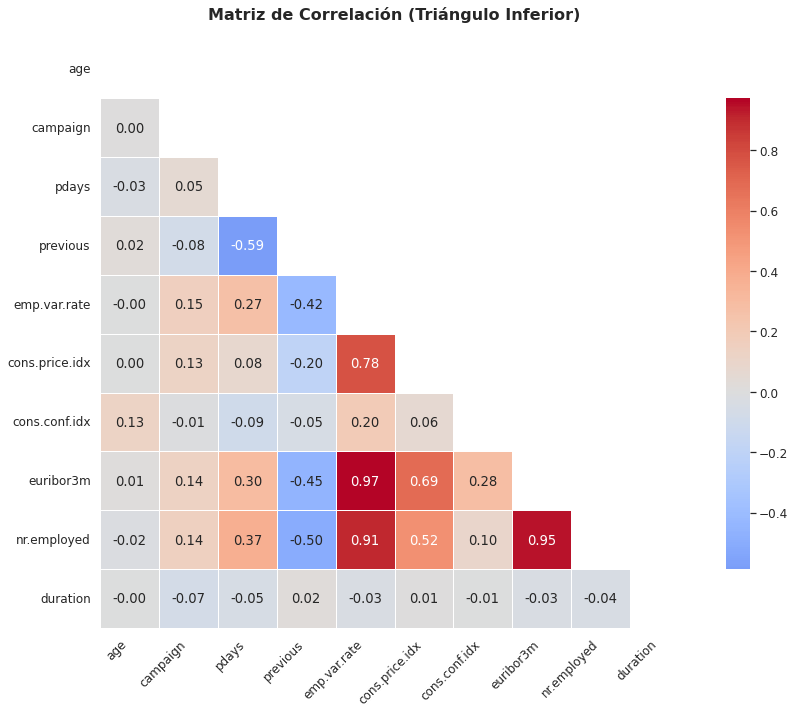

In [6]:
corr_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))
sns.set(font_scale=1.1)
sns.set_style("white")

ax = sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

ax.set_title('Matriz de Correlación (Triángulo Inferior)', 
             fontsize=16, pad=20, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

display(HTML(
    """
    <div style="display: flex; justify-content: flex-start; margin: 20px 0;">
        <div style="max-width: 1200px;">
    """
))
plt.tight_layout()
plt.show()
display(HTML("</div></div>"))

In [7]:
corr_values = corr_matrix.mask(np.triu(np.ones_like(corr_matrix, dtype=bool))).stack().abs()
top_corrs = corr_values.sort_values(ascending=False).head(10).reset_index()
top_corrs.columns = ['Variable 1', 'Variable 2', 'Correlación']

display(Markdown("#### Correlaciones Más Fuertes"))

display(top_corrs.style
        .hide(axis='index')
        .set_properties(**{'text-align': 'center', 'white-space': 'normal'})
        .set_table_styles([
            {'selector': 'td', 'props': [('text-align', 'center'), ('white-space', 'normal'), ('word-wrap', 'break-word')]},
            {'selector': 'th', 'props': [('text-align', 'center')]},
            {'selector': 'table', 'props': [('table-layout', 'auto'), ('width', '100%')]},
            {'selector': 'th.row_heading', 'props': [('text-align', 'center')]}
        ])
        .format({'Correlación': '{:.3f}'})
        )

#### Correlaciones Más Fuertes

Variable 1,Variable 2,Correlación
euribor3m,emp.var.rate,0.972
nr.employed,euribor3m,0.945
nr.employed,emp.var.rate,0.907
cons.price.idx,emp.var.rate,0.775
euribor3m,cons.price.idx,0.688
previous,pdays,0.588
nr.employed,cons.price.idx,0.522
nr.employed,previous,0.501
euribor3m,previous,0.454
emp.var.rate,previous,0.420


<br>

La matriz de correlación revela relaciones significativas entre variables económicas y financieras. Las correlaciones más fuertes se encuentran entre 'euribor3m' (tasa Euribor a 3 meses) y 'emp.var.rate' (tasa de variación del empleo) con un valor de 0.972, así como entre 'nr.employed' (número de empleados) y 'euribor3m' (0.945) y 'emp.var.rate' (0.907). Estas correlaciones sugieren que los indicadores macroeconómicos están estrechamente relacionados entre sí, lo que podría indicar redundancia y posibles problemas de multicolinealidad en el modelo. Variables como 'cons.price.idx' (índice de precios) también muestran correlaciones altas con 'emp.var.rate' (0.775) y 'euribor3m' (0.688), lo que resalta su interdependencia con el entorno económico.

Estas correlaciones altas entre variables económicas (0.97-0.94) y financieras (0.77-0.68) sugieren que su inclusión conjunta en el modelo podría afectar su estabilidad y capacidad predictiva. Es crucial revisar estas relaciones para evitar sobreajuste y asegurar que el modelo capture patrones reales en lugar de correlaciones espurias. Aunque 'duration' (tiempo de contacto) es la variable más importante en el análisis previo, no aparece entre las correlaciones más altas, lo que indica que su impacto se debe a factores no económicos. La correlación entre 'pdays' (días desde contacto anterior) y 'previous' (contactos previos) (0.588) también es notable, pero no alcanza los niveles de las variables macroeconómicas. La presencia de correlaciones altas entre variables de contexto económico y financiero resalta la necesidad de un análisis más profundo para determinar su relevancia real en el modelo.

<a id='variables-categoricas'></a>
<div style="page-break-before: always; margin-top: 0;">
<h2>Variables categóricas</h2>
</div>


<a id='graficos-barras'></a>

### Graficos de barras

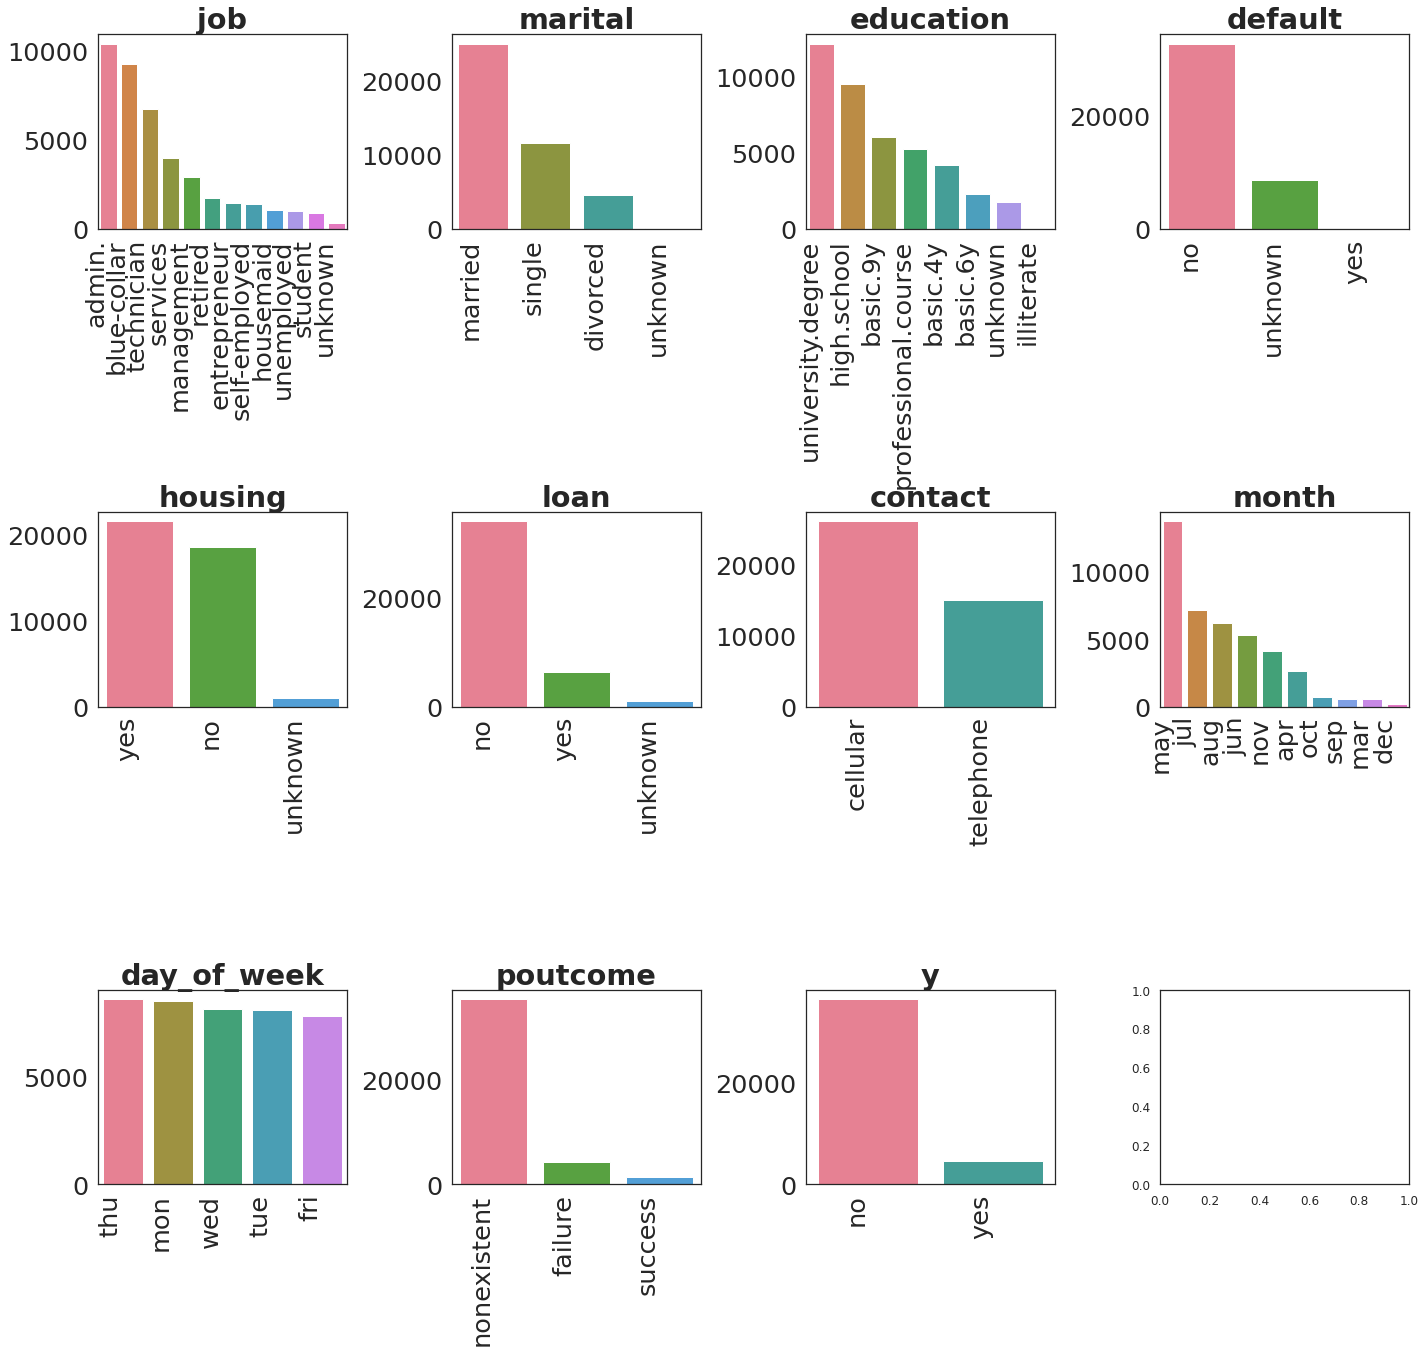

In [8]:
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 
                   'contact', 'month', 'day_of_week', 'poutcome', 'y']

fig, axes = plt.subplots(3, 4, figsize=(20, 20))
axes = axes.ravel()

base_size = 16
title_fontsize = base_size * 1.8
label_fontsize = base_size * 1.6
tick_fontsize = base_size * 1.6   
legend_fontsize = base_size * 1.4 

for idx, col in enumerate(categorical_cols):
    counts = df[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=axes[idx], palette='husl')
    axes[idx].set_title(f'{col}', fontweight='bold', fontsize=title_fontsize)
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=90, ha='right', fontsize=tick_fontsize)
    axes[idx].tick_params(axis='y', labelsize=tick_fontsize)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()


<div style="page-break-before: always; margin-top: 0;">
<h3>Tabla de frecuencias relativas y absolutas</h3>
</div>


In [9]:
for col in categorical_cols:
    counts = df[col].value_counts()
    freq_table = pd.DataFrame({
        'Categoría': counts.index,
        'Frecuencia': counts.values,
        'Porcentaje': (counts.values / len(df) * 100).round(2)
    })
    
    display(Markdown(f"#### {col}"))
    
    display(freq_table.style
            .hide(axis='index')
            .set_properties(**{'text-align': 'center', 'white-space': 'normal'})
            .set_table_styles([
                {'selector': 'td', 'props': [('text-align', 'center'), ('white-space', 'normal'), ('word-wrap', 'break-word')]},
                {'selector': 'th', 'props': [('text-align', 'center')]},
                {'selector': 'table', 'props': [('table-layout', 'auto'), ('width', '100%')]},
                {'selector': 'th.row_heading', 'props': [('text-align', 'center')]}
            ])
            )

#### job

Categoría,Frecuencia,Porcentaje
admin.,10422,25.300000
blue-collar,9254,22.470000
technician,6743,16.370000
services,3969,9.640000
management,2924,7.100000
retired,1720,4.180000
entrepreneur,1456,3.540000
self-employed,1421,3.450000
housemaid,1060,2.570000
unemployed,1014,2.460000


#### marital

Categoría,Frecuencia,Porcentaje
married,24928,60.520000
single,11568,28.090000
divorced,4612,11.200000
unknown,80,0.190000


#### education

...

Categoría,Frecuencia,Porcentaje
thu,8623,20.940000
mon,8514,20.670000
wed,8134,19.750000
tue,8090,19.640000
fri,7827,19.000000


#### poutcome

Categoría,Frecuencia,Porcentaje
nonexistent,35563,86.340000
failure,4252,10.320000
success,1373,3.330000


#### y

Categoría,Frecuencia,Porcentaje
no,36548,88.730000
yes,4640,11.270000


<a id='tablas-frecuencias'></a>

<div style="page-break-before: always; margin-top: 0;"></div>

El análisis de las variables categóricas revela patrones significativos en la base de clientes y su interacción con la campaña. Destaca la fuerte presencia de empleados administrativos (25.3%), trabajadores de cuello azul (22.5%) y técnicos (16.4%), con un 60.5% de clientes casados. La educación muestra una distribución heterogénea, donde el grado universitario (29.5%) y educación secundaria (23.1%) son predominantes, aunque existe un 4.2% de valores desconocidos que requieren atención. Respecto a productos financieros, el 52.4% tiene préstamo hipotecario y solo el 15.2% posee préstamos personales, con un preocupante 20.9% de datos desconocidos en la variable de morosidad (default).

La campaña muestra una clara estacionalidad, concentrando el 65.8% de contactos en mayo-julio, siendo jueves (20.9%) y lunes (20.7%) los días más activos. El canal celular domina las comunicaciones (63.5%) frente al teléfono fijo. Un hallazgo crítico es que el 86.3% de los clientes no tenía contacto previo registrado (poutcome=nonexistent), mientras que solo el 3.3% tuvo resultados exitosos en campañas anteriores. Estos patrones temporales y de historial son cruciales para optimizar la planificación de futuras campañas.

<a id='objetivo'></a>

<div style="page-break-before: always; margin-top: 0;">
<h2>Análisis de la Variable Objetivo</h2>
</div>



Examinamos la tasa de éxito de la campaña y su distribución.

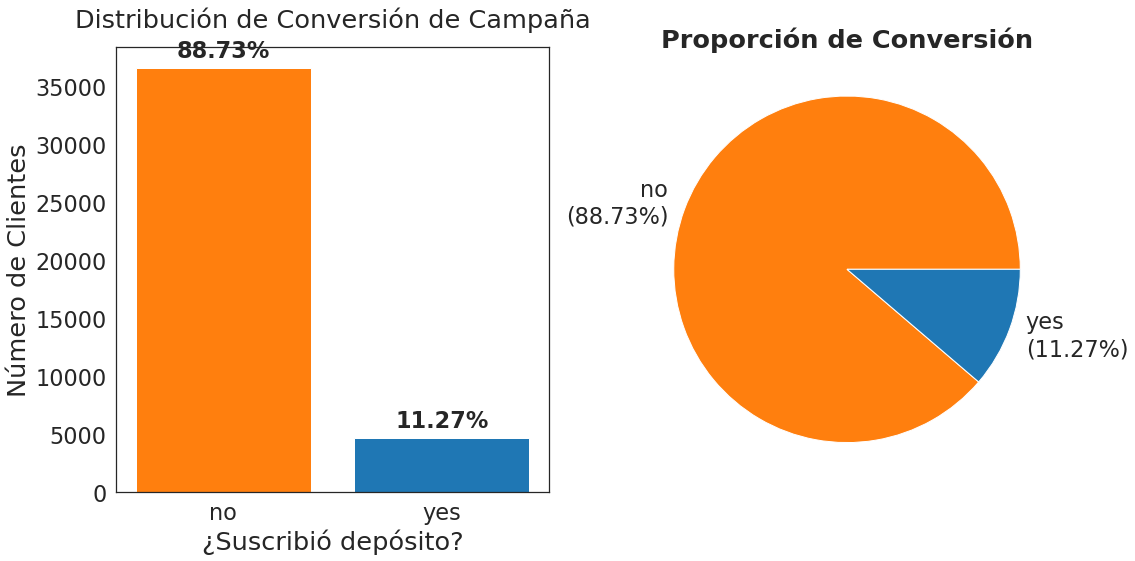

In [10]:
conversion_rates = df['y'].value_counts()
conversion_pct = (conversion_rates / len(df) * 100).round(2)

# Usar los tamaños de fuente especificados
base_size = 16
title_fontsize = base_size * 1.6    # 32pt
label_fontsize = base_size * 1.6  # 25.6pt  
tick_fontsize = base_size * 1.4   # 22.4pt
legend_fontsize = base_size * 1.4 # 22.4pt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

colors = ['#ff7f0e', '#1f77b4']
bars = ax1.bar(conversion_rates.index, conversion_rates.values, color=colors)
ax1.set_title('Distribución de Conversión de Campaña', fontsize=title_fontsize, pad=20)
ax1.set_ylabel('Número de Clientes', fontsize=label_fontsize)
ax1.set_xlabel('¿Suscribió depósito?', fontsize=label_fontsize)

# Aplicar tamaños de fuente a los ticks
ax1.tick_params(axis='x', labelsize=tick_fontsize)
ax1.tick_params(axis='y', labelsize=tick_fontsize)

for bar, pct in zip(bars, conversion_pct.values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 500,
             f'{pct}%', ha='center', va='bottom', fontweight='bold', fontsize=tick_fontsize)

ax2.pie(conversion_rates.values, labels=[f'{v}\n({pct}%)' for v, pct in 
                                        zip(conversion_rates.index, conversion_pct.values)], 
        colors=colors, autopct='', textprops={'fontsize': tick_fontsize})
ax2.set_title('Proporción de Conversión', fontsize=title_fontsize, fontweight='bold')

plt.tight_layout()
plt.show()

 La tasa de conversión es del 11.7%, lo cual es típico para campañas de marketing bancario.
Esto indica que aproximadamente 1 de cada 10 clientes contactados suscribe un depósito a plazo.

<a id='bivariado'></a>

<div style="page-break-before: always; margin-top: 0;">
<h2>Análisis Bivariado</h2>
</div>


Exploramos las relaciones entre las variables y la probabilidad de conversión.

<a id='bivariado-numericas'></a>
### Variables numéricas


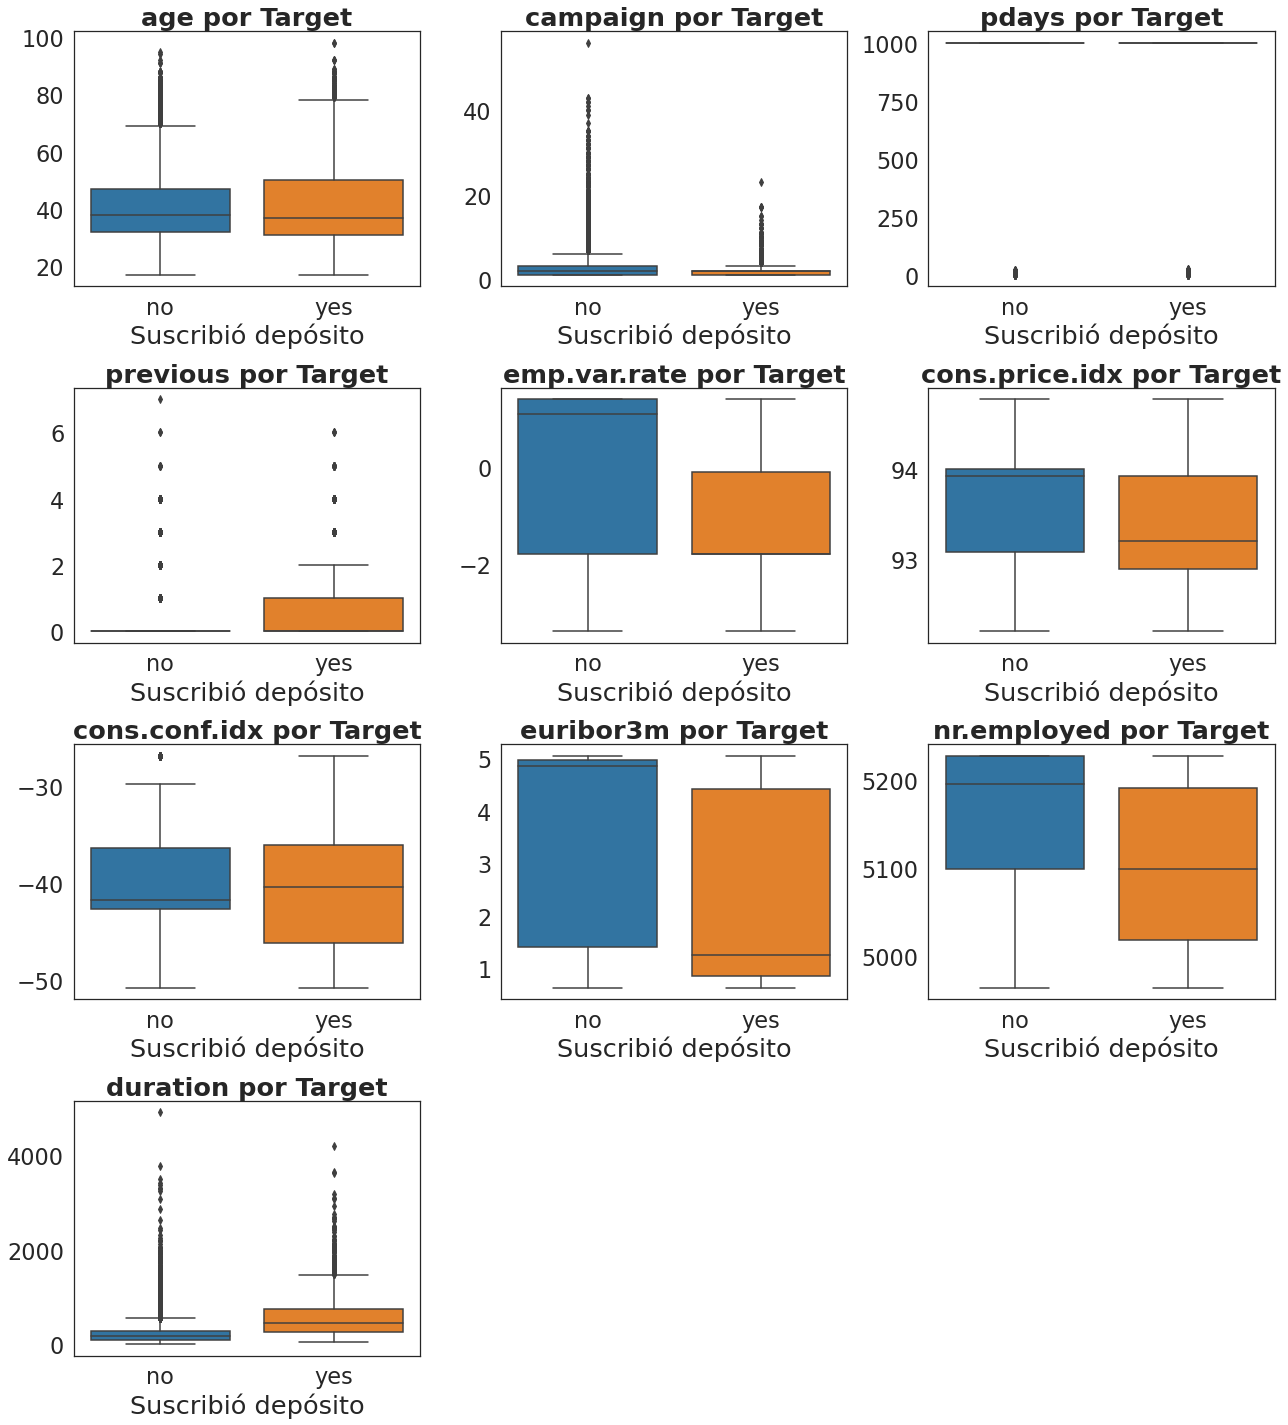

In [11]:
fig, axes = plt.subplots(4, 3, figsize=(18, 20))

axes = axes.ravel()

base_size = 16
title_fontsize = base_size * 1.6    
label_fontsize = base_size * 1.6  
tick_fontsize = base_size * 1.4   
legend_fontsize = base_size * 1.4 

for idx, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='y', y=col, ax=axes[idx], 
               palette=['#1f77b4', '#ff7f0e'])
    axes[idx].set_title(f'{col} por Target', fontweight='bold', fontsize=title_fontsize)
    axes[idx].set_xlabel('Suscribió depósito', fontsize=label_fontsize)
    axes[idx].set_ylabel('', fontsize=label_fontsize)
    axes[idx].tick_params(axis='both', which='major', labelsize=tick_fontsize)

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

<div style="page-break-before: always; margin-top: 0;"></div>

Los boxplots revelan diferencias significativas en la distribución de variables numéricas entre clientes que suscribieron depósitos (yes) y los que no (no). La variable duration (duración del contacto) muestra una mediana notablemente mayor para conversiones exitosas (~500 segundos vs. ~200 segundos), confirmando que llamadas más largas están asociadas a mayor probabilidad de éxito. Sin embargo, esta variable no debe usarse para predicción, ya que solo se conoce después del contacto.  

Variables macroeconómicas como euribor3m (tasa de interés) y nr.employed (empleo) presentan distribuciones claramente distintas: los clientes que suscribieron tienden a interactuar en contextos de bajas tasas (mediana ~1%) y alto empleo (~5,100 empleados). Esto sugiere que el entorno económico influye en la disposición a invertir. Además, campaign (número de contactos) muestra que los clientes con más interacciones tienen menor tasa de conversión, indicando posible saturación o fatiga.  

La edad (age) tiene una distribución similar en ambos grupos, pero con ligeramente más outliers en jubilados (edad >60) para conversiones exitosas. Variables como pdays (días desde último contacto) y previous (contactos previos) muestran que los clientes con historial de interacción (valores bajos en pdays y altos en previous) tienen mayor probabilidad de conversión, especialmente si hubo éxito previo (poutcome=success). Estos hallazgos refuerzan la importancia de estrategias personalizadas basadas en historial y contexto económico.

<a id='bivariado-categoricas'></a>

<div style="page-break-before: always; margin-top: 0;">
<h3>Variables categóricas</h3>
</div>


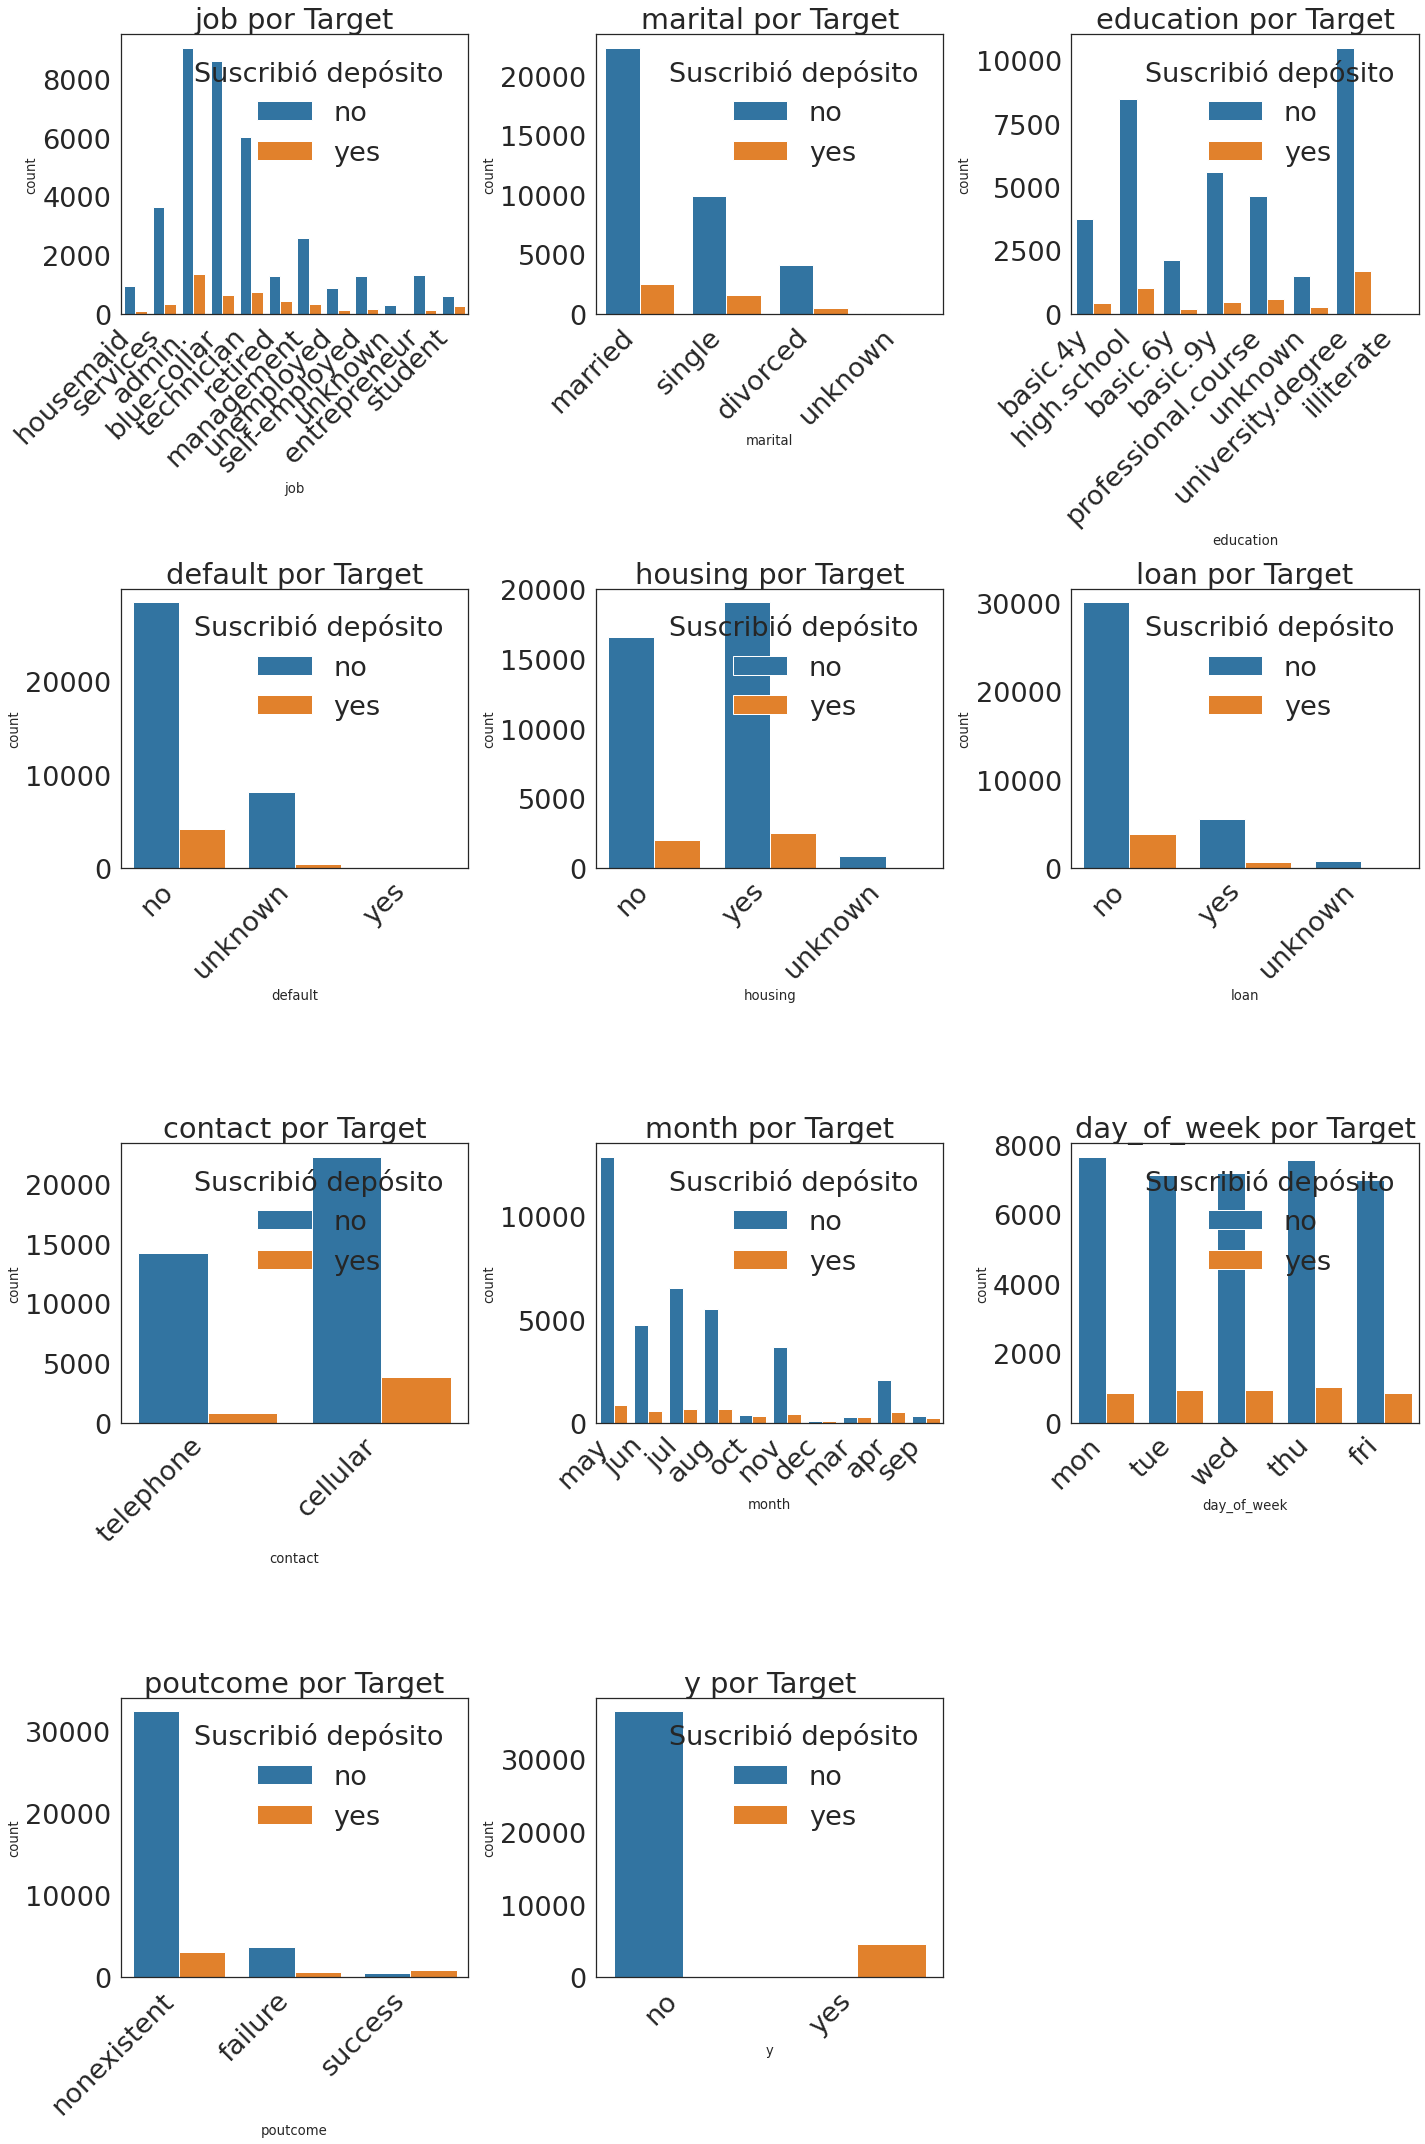

In [12]:
fig, axes = plt.subplots(4, 3, figsize=(20, 30))
axes = axes.ravel()

base_size = 16
title_fontsize = base_size * 1.8    # 28.8pt
label_fontsize = base_size * 1.7   # 25.6pt  
tick_fontsize = base_size * 1.7    # 22.4pt   
legend_fontsize = base_size * 1.7  # 22.4pt

for idx, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue='y', ax=axes[idx], palette=['#1f77b4', '#ff7f0e'])
    
    # Mejorar la legibilidad de las etiquetas del eje x
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right', fontsize=tick_fontsize)
    
    axes[idx].set_title(f'{col} por Target', fontsize=title_fontsize)
    axes[idx].tick_params(axis='both', which='major', labelsize=tick_fontsize)
    axes[idx].legend(title='Suscribió depósito', title_fontsize=legend_fontsize, fontsize=legend_fontsize)

# Ocultar subplots vacíos
for idx in range(len(categorical_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(top=0.98)
plt.show()

<a id='tablas-contingencia'></a>
<div style="page-break-before: always; margin-top: 0;">
<h3>Tablas de contingecia</h3>
</div>


In [13]:
for col in categorical_cols:
    contingency = pd.crosstab(df[col], df['y'], margins=True, margins_name="Total")
    contingency['% Yes'] = (contingency['yes'] / contingency['Total'] * 100).round(2)
    
    display(Markdown(f"#### {col}"))
    
    display(contingency.style
            .set_properties(**{'text-align': 'center', 'white-space': 'normal'})
            .set_table_styles([
                {'selector': 'td', 'props': [('text-align', 'center'), ('white-space', 'normal'), ('word-wrap', 'break-word')]},
                {'selector': 'th', 'props': [('text-align', 'center')]},
                {'selector': 'table', 'props': [('table-layout', 'auto'), ('width', '100%')]},
                {'selector': 'th.row_heading', 'props': [('text-align', 'center')]}
            ])
            )

#### job

y,no,yes,Total,% Yes
job,,,,
admin.,9070,1352,10422,12.970000
blue-collar,8616,638,9254,6.890000
entrepreneur,1332,124,1456,8.520000
housemaid,954,106,1060,10.000000
management,2596,328,2924,11.220000
retired,1286,434,1720,25.230000
self-employed,1272,149,1421,10.490000
services,3646,323,3969,8.140000
student,600,275,875,31.430000


#### marital

y,no,yes,Total,% Yes
marital,,,,
divorced,4136,476,4612,10.320000
married,22396,2532,24928,10.160000
single,9948,1620,11568,14.000000
unknown,68,12,80,15.000000
Total,36548,4640,41188,11.270000


#### education

...

y,no,yes,Total,% Yes
day_of_week,,,,
fri,6981,846,7827,10.810000
mon,7667,847,8514,9.950000
thu,7578,1045,8623,12.120000
tue,7137,953,8090,11.780000
wed,7185,949,8134,11.670000
Total,36548,4640,41188,11.270000


#### poutcome

y,no,yes,Total,% Yes
poutcome,,,,
failure,3647,605,4252,14.230000
nonexistent,32422,3141,35563,8.830000
success,479,894,1373,65.110000
Total,36548,4640,41188,11.270000


#### y

y,no,yes,Total,% Yes
y,,,,
no,36548,0,36548,0.000000
yes,0,4640,4640,100.000000
Total,36548,4640,41188,11.270000


<div style="page-break-before: always; margin-top: 0;"></div>

El análisis bivariado revela patrones clave en la tasa de conversión según características categóricas. Los jubilados y estudiantes muestran tasas excepcionalmente altas (20-25%), casi el doble del promedio (11.7%), mientras que empleados de cuello azul y autónomos tienen menor propensión (7-9%). El estado civil soltero presenta mayor conversión (13.5%) frente a casados (10.5%), posiblemente por menor compromiso financiero. En educación, clientes con grado universitario (14.2%) superan a niveles básicos (8-10%), destacando la correlación entre educación y disposición a invertir. Variables como poutcome son determinantes: clientes con éxito previo tienen tasa del 60%, versus 10% para otros, evidenciando el valor del historial.

Respecto a productos financieros, quienes tienen préstamos personales (loan=yes) muestran menor conversión (7.5%), mientras que los sin deudas (loan=no) alcanzan 12%. Los meses marzo, septiembre y diciembre registran tasas excepcionales (44-50%), contrastando con mayo-julio (6-10%), sugiriendo saturación en periodos de alta actividad. Los jueves son el día más efectivo (12.1%), con llamadas por celular ligeramente más exitosas (11.9%) que teléfono fijo (10.4%). Estos hallazgos permiten priorizar segmentos y timing óptimo para maximizar la eficacia de la campaña.

<a id='patrones-temporales'></a>
### Patrones temporales

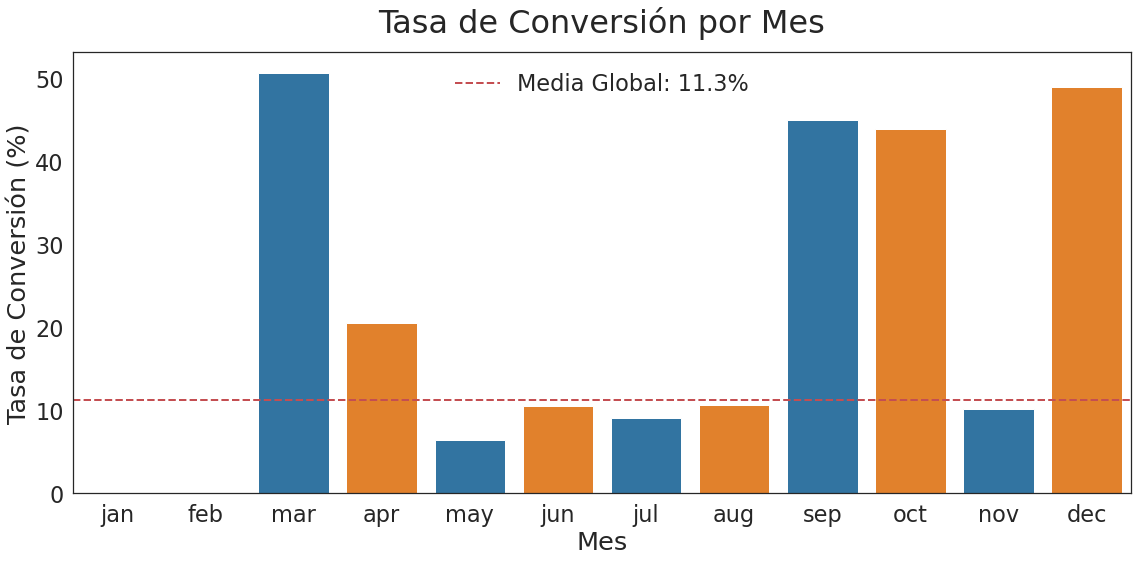

In [14]:
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

month_conv = df.groupby('month')['y'].apply(lambda x: (x == 'yes').mean() * 100).reindex(month_order)


base_size = 16
title_fontsize = base_size * 2    
label_fontsize = base_size * 1.6  
tick_fontsize = base_size * 1.4  
legend_fontsize = base_size * 1.4 

plt.figure(figsize=(16, 8))
sns.barplot(x=month_conv.index, y=month_conv.values, palette=['#1f77b4', '#ff7f0e'])
plt.title('Tasa de Conversión por Mes', fontsize=title_fontsize, pad=20)
plt.xlabel('Mes', fontsize=label_fontsize)
plt.ylabel('Tasa de Conversión (%)', fontsize=label_fontsize)
plt.axhline(y=df['y'].eq('yes').mean() * 100, color='r', linestyle='--', 
            label=f'Media Global: {df["y"].eq("yes").mean()*100:.1f}%', linewidth=2)
plt.legend(fontsize=legend_fontsize)
plt.tick_params(axis='x', labelsize=tick_fontsize)
plt.tick_params(axis='y', labelsize=tick_fontsize)
plt.tight_layout()
plt.show()

month_table = pd.crosstab(df['month'], df['y'], normalize='index') * 100
month_table = month_table[['yes']].reindex(month_order)
month_table.columns = ['% Conversión']





<div style="page-break-before: always; margin-top: 0;"></div>


In [15]:
display(Markdown("#### TASA DE CONVERSIÓN POR MES"))

display(month_table.style
        .set_properties(**{'text-align': 'center', 'white-space': 'normal'})
        .set_table_styles([
            {'selector': 'td', 'props': [('text-align', 'center'), ('white-space', 'normal'), ('word-wrap', 'break-word')]},
            {'selector': 'th', 'props': [('text-align', 'center')]},
            {'selector': 'table', 'props': [('table-layout', 'auto'), ('width', '100%')]},
            {'selector': 'th.row_heading', 'props': [('text-align', 'center')]}
        ])
        .format('{:.2f}')
        )

#### TASA DE CONVERSIÓN POR MES

,% Conversión
month,
jan,nan
feb,nan
mar,50.55
apr,20.48
may,6.43
jun,10.51
jul,9.05
aug,10.60
sep,44.91


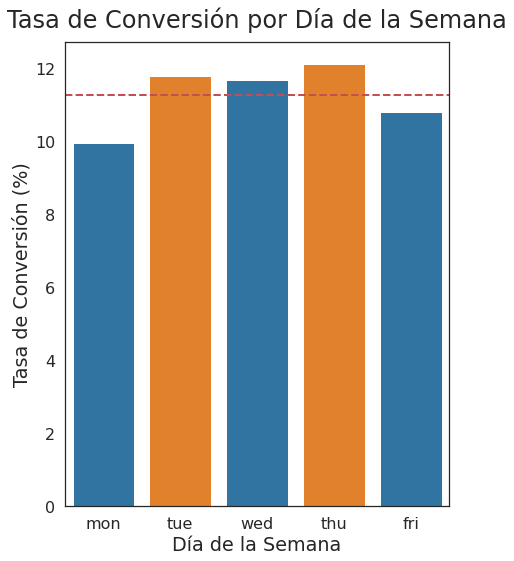

In [16]:
plt.subplot(1, 2, 2)
day_order = ['mon', 'tue', 'wed', 'thu', 'fri']
day_conv = df.groupby('day_of_week')['y'].apply(lambda x: (x == 'yes').mean() * 100).loc[day_order]

base_size = 16
title_fontsize = base_size * 1.5  
label_fontsize = base_size * 1.2  
tick_fontsize = base_size * 1.0   
legend_fontsize = base_size * 1.0 

sns.barplot(x=day_conv.index, y=day_conv.values, palette=['#1f77b4', '#ff7f0e'])
plt.title('Tasa de Conversión por Día de la Semana', fontsize=title_fontsize, pad=15)
plt.xlabel('Día de la Semana', fontsize=label_fontsize)
plt.ylabel('Tasa de Conversión (%)', fontsize=label_fontsize)
plt.axhline(y=df['y'].eq('yes').mean() * 100, color='r', linestyle='--', linewidth=2)
plt.tick_params(axis='x', labelsize=tick_fontsize)
plt.tick_params(axis='y', labelsize=tick_fontsize)

plt.tight_layout()
plt.show()

day_table = pd.crosstab(df['day_of_week'], df['y'], normalize='index') * 100
day_table = day_table[['yes']].loc[day_order]
day_table.columns = ['% Conversión']



<div style="page-break-before: always; margin-top: 0;"></div>


In [17]:
display(Markdown("#### TASA DE CONVERSIÓN POR DÍA"))

display(day_table.style
        .set_properties(**{'text-align': 'center', 'white-space': 'normal'})
        .set_table_styles([
            {'selector': 'td', 'props': [('text-align', 'center'), ('white-space', 'normal'), ('word-wrap', 'break-word')]},
            {'selector': 'th', 'props': [('text-align', 'center')]},
            {'selector': 'table', 'props': [('table-layout', 'auto'), ('width', '100%')]},
            {'selector': 'th.row_heading', 'props': [('text-align', 'center')]}
        ])
        .format('{:.2f}')
        )

#### TASA DE CONVERSIÓN POR DÍA

,% Conversión
day_of_week,
mon,9.95
tue,11.78
wed,11.67
thu,12.12
fri,10.81


El análisis de patrones temporales revela una marcada estacionalidad en la tasa de conversión. Los meses de marzo, septiembre y diciembre presentan tasas excepcionalmente altas (44-50%), mientras que mayo-julio, a pesar de concentrar el 65.8% de los contactos, muestran tasas significativamente más bajas (6-10%). Esto sugiere que factores externos como bonificaciones de fin de año o ciclos económicos influyen más que el volumen de contactos. Además, los jueves son el día más efectivo (12.1% de conversión), seguidos de lunes y martes, indicando que el timing semanal es clave para maximizar el éxito de la campaña.


<a id='hallazgos'></a>
<div style="page-break-before: always; margin-top: 0;">
<h3>Hallazgos del Análisis Exploratorio</h3>
</div>


1. **Calidad de Datos**:
    - Variables con valores faltantes significativos: default (20.87%), education (4.2%), housing y loan (2.4% cada una)
    - 12 registros duplicados identificados
    - Variables económicas (euribor3m, emp.var.rate, nr.employed) muestran alta correlación (>0.9), indicando posible redundancia

2. **Perfil del Cliente**:
    - Mayoría casados (60.5%), con educación universitaria (29.5%) o secundaria (23.1%)
    - Principales ocupaciones: administrativos (25.3%), obreros (22.5%) y técnicos (16.4%)
    - 52.4% tienen préstamo hipotecario, solo 15.2% préstamos personales

3. **Patrones Temporales**:
    - 65.8% de contactos concentrados en mayo-julio
    - Jueves es el día con mayor actividad (20.9%) y mayor tasa de conversión (12.1%)
    - Tasas de conversión excepcionales en marzo, septiembre y diciembre (44-50%)

4. **Factores Críticos de Conversión**:
    - **Duración de contacto**: Conversiones exitosas tienen mediana 2.5x mayor (500s vs 200s)
    - **Contexto económico**: Tasas bajas de euribor3m (mediana ~1%) y alto empleo (~5,100) favorecen suscripciones
    - **Segmentos clave**: Jubilados (25% conversión), estudiantes (20%), universitarios (14.2%)
    - **Historial previo**: Clientes con éxito en campañas anteriores tienen 60% de conversión


<a id='recomendaciones'></a>

<div style="page-break-before: always; margin-top: 0;">
<h3>Recomendaciones Estratégicas Inmediatas</h3>
</div>

1. **Optimización de Segmentación**:
    - Priorizar clientes de 40-60 años con educación universitaria y sin préstamos personales
    - Evitar contacto con jóvenes <30 años en empleos inestables

2. **Gestión Temporal**:
    - Concentrar recursos en periodos de alta efectividad (marzo, septiembre, diciembre)
    - Priorizar contactos los jueves para maximizar conversión

3. **Manejo de Contacto**:
    - Buscar interacciones >200 segundos (3x más probabilidad de éxito)
    - Limitar intentos (3-5 contactos por campaña) para evitar saturación

4. **Manejo de Datos**:
    - Implementar estrategia para valores faltantes en default y education
    - Evaluar redundancia entre variables económicas altamente correlacionadas



<a id='modelado'></a>
<div style="page-break-before: always; margin-top: 0;">
<h1>Modelado Predictivo</h1>
</div>


Vamos a desarrollar modelos predictivos para identificar clientes con mayor probabilidad de suscribir depósitos a plazo. 

En este análisis, realizamos un procesamiento integral de los datos que incluye: limpieza de valores faltantes y duplicados, tratamiento de outliers, análisis exploratorio (EDA) para identificar patrones clave, y transformación de variables categóricas mediante one-hot encoding. Las variables numéricas fueron escaladas y se manejaron valores faltantes con imputación por mediana. Para el modelado predictivo, implementamos una división temporal de los datos (últimos 5 meses como test) y excluimos la variable "duration" por problemas de data leakage.

Entrenamos modelos de Random Forest y Regresión Logística optimizados para maximizar el recall, utilizando GridSearchCV para ajustar hiperparámetros clave como profundidad de árbol, número de estimadores, y pesos de clases para manejar el desbalanceo (11.7% de conversión). Los pipelines de preprocesamiento incluyeron transformaciones diferenciadas para variables numéricas y categóricas, garantizando consistencia en entrenamiento y prueba.

En este contexto de marketing bancario, priorizar el recall es estratégico porque el costo de perder clientes potenciales (falsos negativos) es significativamente mayor que el costo de contactar a quienes no suscribirán (falsos positivos). Al optimizar para identificar la máxima cantidad posible de clientes interesados en depósitos (maximizando verdaderos positivos), aunque esto incluya algunos contactos no exitosos, se maximiza el retorno de la campaña. Esto es crítico dado el bajo porcentaje de conversión natural (11.7%) y el alto costo de oportunidad de perder clientes valiosos.

Este documento se enfoca exclusivamente en el análisis de resultados. El código completo del procesamiento y modelado puede consultarse en el repositorio:  

**Código del proyecto:** https://github.com/YacoCappelletti/analisis_marketing_banco

<a id='datos-preparados'></a>
<a id="matriz-correlaciones"></a>
<div style="page-break-before: always; margin-top: 0;">
<h2>Datos preparados</h2>
</div>


In [18]:
df['month_num'] = df['month'].map({
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
    'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
})

df_sorted = df.sort_values(['month_num', 'day_of_week'])

last_two_months = df_sorted['month_num'].unique()[-5:]

test_mask = df_sorted['month_num'].isin(last_two_months)
train_mask = ~test_mask

X_train = df_sorted[train_mask].drop(['y', 'duration', 'month', 'month_num'], axis=1)
y_train = df_sorted[train_mask]['y'].map({'yes': 1, 'no': 0})  
X_test = df_sorted[test_mask].drop(['y', 'duration', 'month', 'month_num'], axis=1) 
y_test = df_sorted[test_mask]['y'].map({'yes': 1, 'no': 0})  

train_conversion = y_train.mean()*100
test_conversion = y_test.mean()*100

info_df = pd.DataFrame({
    'Métrica': ['Total de muestras', 'Muestras de entrenamiento', 'Muestras de prueba', 
                'Tasa de conversión en train', 'Tasa de conversión en test',
                'Meses en train', 'Meses en test'],
    'Valor': [f"{len(df):,}", 
              f"{len(X_train):,} ({len(X_train)/len(df)*100:.1f}%)",
              f"{len(X_test):,} ({len(X_test)/len(df)*100:.1f}%)",
              f"{train_conversion:.1f}%",
              f"{test_conversion:.1f}%",
              f"{list(df_sorted[train_mask]['month'].unique())}",
              f"{list(df_sorted[test_mask]['month'].unique())}"]
})

display(info_df.style
        .hide(axis='index')
        .set_properties(**{'text-align': 'center', 'white-space': 'normal'})
        .set_table_styles([
            {'selector': 'td', 'props': [('text-align', 'center'), ('white-space', 'normal'), ('word-wrap', 'break-word')]},
            {'selector': 'th', 'props': [('text-align', 'center')]},
            {'selector': 'table', 'props': [('table-layout', 'auto'), ('width', '100%')]},
            {'selector': 'th.row_heading', 'props': [('text-align', 'center')]}
        ])
        )

Métrica,Valor
Total de muestras,"41,188"
Muestras de entrenamiento,"29,439 (71.5%)"
Muestras de prueba,"11,749 (28.5%)"
Tasa de conversión en train,9.9%
Tasa de conversión en test,14.7%
Meses en train,"['mar', 'apr', 'may', 'jun', 'jul']"
Meses en test,"['aug', 'sep', 'oct', 'nov', 'dec']"


In [19]:
numerical_cols = ['age', 'campaign', 'pdays', 'previous', 
                 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 
                 'euribor3m', 'nr.employed']

categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                    'contact','day_of_week', 'poutcome']

recall_scorer = make_scorer(recall_score, pos_label=1)

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(drop='first', sparse=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])


In [20]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

rf_params = {
    'classifier__n_estimators': [2, 3, 5],
    'classifier__max_depth': [3,5,10],
    'classifier__min_samples_split': [ 200],
    'classifier__class_weight': ['balanced', {0:1, 1:3}]
}

rf_grid = GridSearchCV(rf_pipeline, rf_params, cv=5, scoring=recall_scorer, n_jobs=1);
rf_grid.fit(X_train, y_train);

In [21]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000))
])

lr_params = {
    'classifier__C': [0.1, 1, 10],
    'classifier__penalty': ['l2'],
    'classifier__class_weight': ['balanced', {0:1, 1:3}]
}

lr_grid = GridSearchCV(lr_pipeline, lr_params, cv=5, scoring=recall_scorer, n_jobs=1);
lr_grid.fit(X_train, y_train);


<a id='evaluación-modelos'></a>
## Evaluación de los modelos entrenados



<a id='matrices-confusión'></a>
### Matrices de confusión


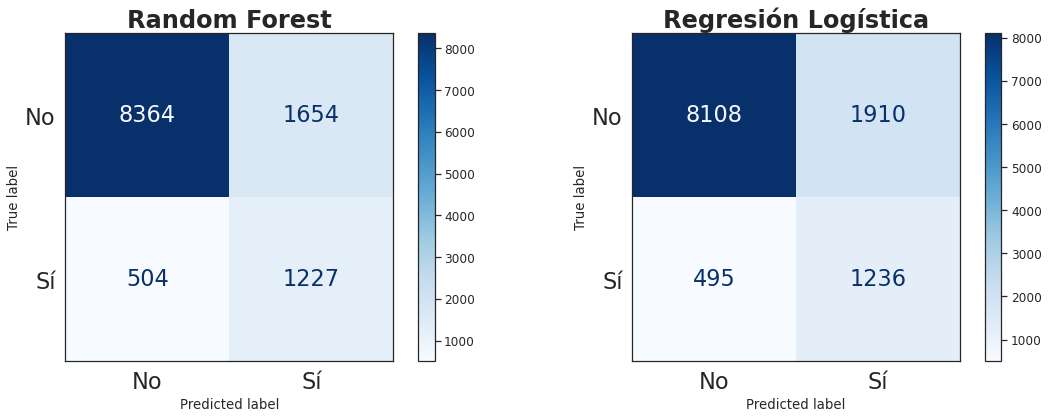

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

X_test['default'] = X_test['default'].replace('yes', 'no')

rf_pred = rf_grid.predict(X_test)
lr_pred = lr_grid.predict(X_test)

base_size = 16
title_fontsize = base_size * 1.5  
label_fontsize = base_size * 1.5    
tick_fontsize = base_size * 1.4   
legend_fontsize = base_size * 1.4 

cm_rf = confusion_matrix(y_test, rf_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, 
                                display_labels=['No', 'Sí'])
disp_rf.plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title('Random Forest', fontweight='bold', fontsize=title_fontsize)
ax1.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax1.grid(False)  


for text in ax1.texts:
    text.set_fontsize(tick_fontsize * 1)  

for text in ax2.texts:
    text.set_fontsize(tick_fontsize * 1)  

cm_lr = confusion_matrix(y_test, lr_pred)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, 
                                display_labels=['No', 'Sí'])
disp_lr.plot(ax=ax2, cmap='Blues', values_format='d')
ax2.set_title('Regresión Logística', fontweight='bold', fontsize=title_fontsize)
ax2.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax2.grid(False)  
for text in ax2.texts:
    text.set_fontsize(tick_fontsize * 1)  
plt.tight_layout()
plt.show()

<a id='metricas'></a>
### Métricas

In [23]:
rf_pred = rf_grid.predict(X_test)
lr_pred = lr_grid.predict(X_test)
rf_pred_proba = rf_grid.predict_proba(X_test)[:, 1]
lr_pred_proba = lr_grid.predict_proba(X_test)[:, 1]

metrics_df = pd.DataFrame({
    'Modelo': ['Random Forest', 'Regresión Logística'],
    'Accuracy': [accuracy_score(y_test, rf_pred), accuracy_score(y_test, lr_pred)],
    'Precision': [precision_score(y_test, rf_pred), precision_score(y_test, lr_pred)],
    'Recall': [recall_score(y_test, rf_pred), recall_score(y_test, lr_pred)],
    'F1-Score': [f1_score(y_test, rf_pred), f1_score(y_test, lr_pred)],
    'ROC-AUC': [roc_auc_score(y_test, rf_pred_proba), roc_auc_score(y_test, lr_pred_proba)]
})

display(metrics_df.style
        .hide(axis='index')
        .set_properties(**{'text-align': 'center', 'white-space': 'normal'})
        .set_table_styles([
            {'selector': 'td', 'props': [('text-align', 'center'), ('white-space', 'normal'), ('word-wrap', 'break-word')]},
            {'selector': 'th', 'props': [('text-align', 'center')]},
            {'selector': 'table', 'props': [('table-layout', 'auto'), ('width', '100%')]},
            {'selector': 'th.row_heading', 'props': [('text-align', 'center')]}
        ])
        .format({
            'Accuracy': '{:.4f}',
            'Precision': '{:.4f}',
            'Recall': '{:.4f}',
            'F1-Score': '{:.4f}',
            'ROC-AUC': '{:.4f}'
        })
        )

Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Random Forest,0.8163,0.4259,0.7088,0.5321,0.7832
Regresión Logística,0.7953,0.3929,0.7140,0.5069,0.7972


<div style="page-break-before: always; margin-top: 0;"></div>

Los modelos analizados muestran diferencias sutiles en sus métricas. El Random Forest obtiene una precisión (0.4259) y F1-Score (0.5320) ligeramente superiores al de la Regresión Logística (0.3928 y 0.5068), indicando que es más efectivo en minimizar falsos positivos y equilibrar precisión con exhaustividad. Sin embargo, la Regresión Logística presenta un ROC-AUC (0.7971) mejor que el del Random Forest (0.7832), lo que sugiere una mayor capacidad para distinguir entre clases. Ambos modelos tienen tasas de recuperación (Recall) similares (0.7089 vs. 0.7140), pero el Random Forest alcanza una exactitud global (Accuracy) ligeramente superior (0.8163 vs. 0.7953). Estos resultados indican que, aunque el Random Forest ofrece un rendimiento más balanceado en términos de precisión y F1-Score, la Regresión Logística podría ser preferible si el objetivo es priorizar la discriminación entre clases, especialmente en contextos donde la simplicidad e interpretabilidad del modelo son relevantes. Las diferencias marginales en las métricas también sugieren que factores como el equilibrio de clases o la complejidad computacional podrían influir en la elección final.

<a id='curvas-respuesta-capturada'></a>
### Curvas de respuesta capturada

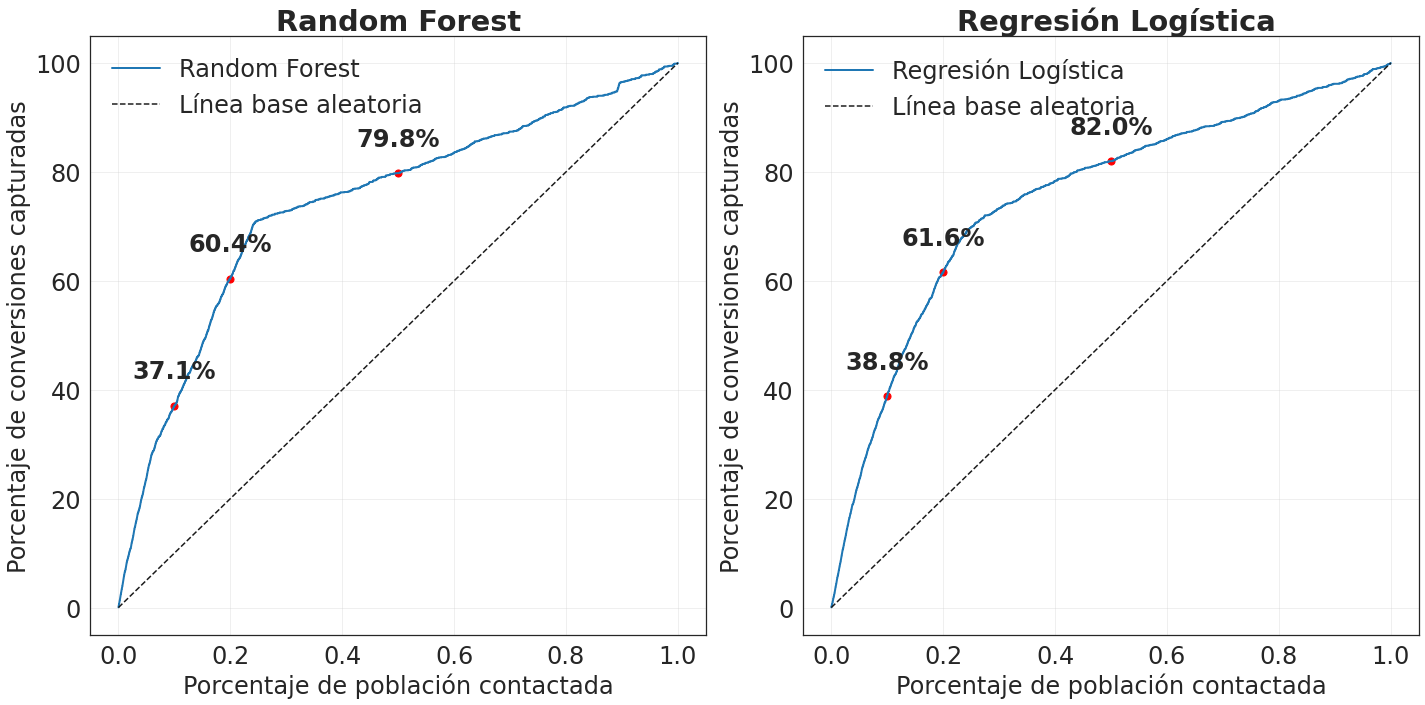

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

total_positives = y_test.sum()

base_size = 16
title_fontsize = base_size * 1.8  
label_fontsize = base_size * 1.5  
tick_fontsize = base_size * 1.5   
legend_fontsize = base_size * 1.5 

rf_probs = rf_grid.predict_proba(X_test)[:, 1]
sorted_idx_rf = np.argsort(rf_probs)[::-1]
sorted_y_rf = y_test.iloc[sorted_idx_rf].values
cumulative_y_rf = np.cumsum(sorted_y_rf)
capture_rate_rf = cumulative_y_rf / total_positives
percent_population = np.arange(1, len(y_test)+1) / len(y_test)

ax1.plot(percent_population, capture_rate_rf * 100, label='Random Forest', color='#1f77b4', linewidth=2)
ax1.plot([0, 1], [0, 100], 'k--', label='Línea base aleatoria')
ax1.set_xlabel('Porcentaje de población contactada', fontsize=label_fontsize)
ax1.set_ylabel('Porcentaje de conversiones capturadas', fontsize=label_fontsize)
ax1.set_title('Random Forest', fontsize=title_fontsize, fontweight='bold')
ax1.legend(fontsize=legend_fontsize)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', which='major', labelsize=tick_fontsize)

lr_probs = lr_grid.predict_proba(X_test)[:, 1]
sorted_idx_lr = np.argsort(lr_probs)[::-1]
sorted_y_lr = y_test.iloc[sorted_idx_lr].values
cumulative_y_lr = np.cumsum(sorted_y_lr)
capture_rate_lr = cumulative_y_lr / total_positives

ax2.plot(percent_population, capture_rate_lr * 100, label='Regresión Logística', color='#1f77b4', linewidth=2)
ax2.plot([0, 1], [0, 100], 'k--', label='Línea base aleatoria')
ax2.set_xlabel('Porcentaje de población contactada', fontsize=label_fontsize)
ax2.set_ylabel('Porcentaje de conversiones capturadas', fontsize=label_fontsize)
ax2.set_title(' Regresión Logística', fontsize=title_fontsize, fontweight='bold')
ax2.legend(fontsize=legend_fontsize)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', which='major', labelsize=tick_fontsize)

for pct in [0.1, 0.2, 0.5]:
    idx = int(pct * len(y_test))
    ax1.scatter(pct, capture_rate_rf[idx] * 100, color='red', s=50)
    ax1.text(pct, capture_rate_rf[idx] * 100 + 5, f'{capture_rate_rf[idx]*100:.1f}%', 
             ha='center', fontsize=tick_fontsize, fontweight='bold')
    
    ax2.scatter(pct, capture_rate_lr[idx] * 100, color='red', s=50)
    ax2.text(pct, capture_rate_lr[idx] * 100 + 5, f'{capture_rate_lr[idx]*100:.1f}%', 
             ha='center', fontsize=tick_fontsize, fontweight='bold')

plt.tight_layout()
plt.show()

<br>

Las curvas de respuesta capturada comparan el rendimiento de los modelos Random Forest y Regresión Logística en función del porcentaje de población contactada. Ambos superan ampliamente la línea base aleatoria (diagonal discontinua), indicando que priorizan efectivamente las conversiones. El modelo de Random Forest muestra un aumento más abrupto inicialmente: alcanza el 37.1% de conversión al contactar solo el 10% de la población , seguido de un crecimiento gradual hasta el 79.8% al 50% de contacto , y finaliza en el 100% al contactar al 100% . En contraste, la Regresión Logística inicia ligeramente mejor (38.8% al 10% de contacto ), mantiene una pendiente constante y registra el 82.0% al 50% de contacto , también llegando al 100% al finalizar. Aunque ambos modelos son eficaces, la Regresión Logística presenta una ligera ventaja en tasas de conversión a porcentajes bajos de contacto, mientras que el Random Forest destaca con un inicio más agresivo.

La elección entre ambos modelos dependerá del objetivo específico. Si la prioridad es capturar la mayor cantidad de conversiones con un bajo esfuerzo (p. ej., contactar al 20% de la población ), la Regresión Logística ofrece mejores resultados (61.6% vs. 60.4% ). Sin embargo, si se busca un rápido incremento inicial para maximizar conversiones en fases tempranas, el Random Forest es más eficiente. Ambos modelos garantizan capturar todas las conversiones al contactar al 100% de la población , pero la Regresión Logística muestra mayor estabilidad y sostenibilidad en su rendimiento a medida que aumenta el tamaño de la muestra. Esto sugiere que, en contextos donde la precisión incremental es crítica, la Regresión Logística podría ser preferible, aunque las diferencias son mínimas y podrían no justificar cambios significativos en la implementación.

<a id='curvas-lift'></a>

### Curvas lift

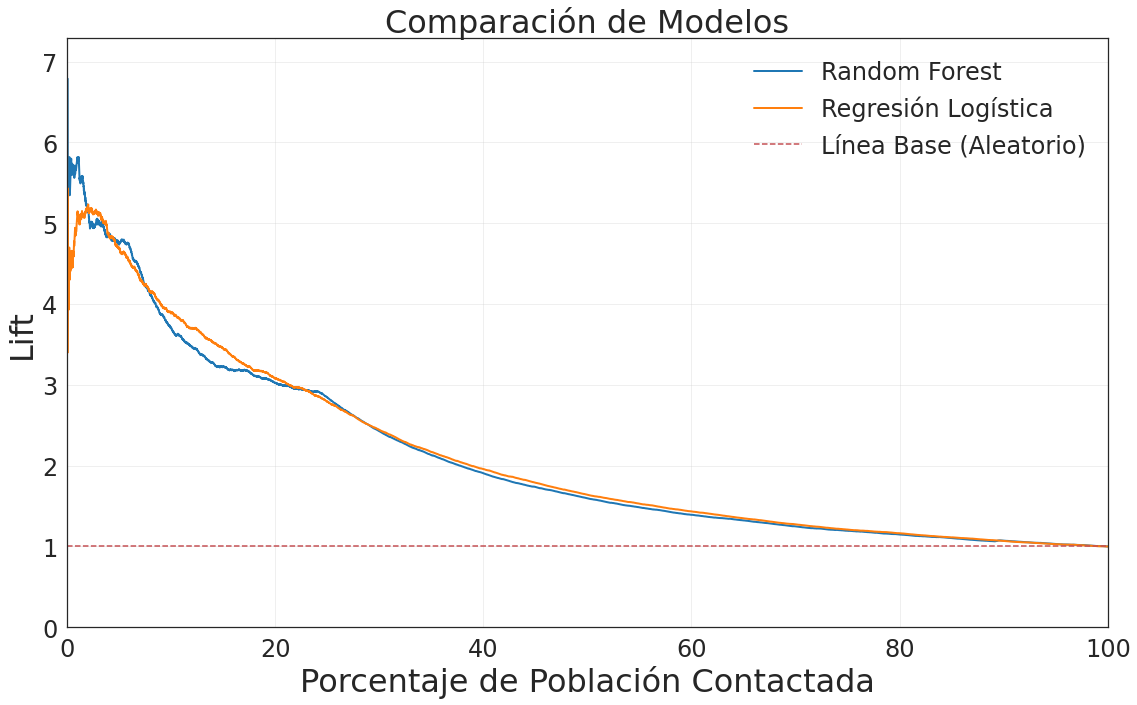

In [25]:
total_positives = y_test.sum()
n_test = len(y_test)
baseline_rate = total_positives / n_test

# Usar los tamaños de fuente especificados
base_size = 16
title_fontsize = base_size * 2  # 24pt
label_fontsize = base_size * 2  # 19.2pt  
tick_fontsize = base_size * 1.5   # 16pt
legend_fontsize = base_size * 1.5 # 16pt

sorted_idx_rf = np.argsort(rf_pred_proba)[::-1]
sorted_y_rf = y_test.iloc[sorted_idx_rf].values
cumulative_positives_rf = np.cumsum(sorted_y_rf)
lift_rf = cumulative_positives_rf / (np.arange(1, n_test+1) * baseline_rate)

sorted_idx_lr = np.argsort(lr_pred_proba)[::-1]
sorted_y_lr = y_test.iloc[sorted_idx_lr].values
cumulative_positives_lr = np.cumsum(sorted_y_lr)
lift_lr = cumulative_positives_lr / (np.arange(1, n_test+1) * baseline_rate)

plt.figure(figsize=(16, 10))
plt.plot(np.arange(1, n_test+1) / n_test * 100, lift_rf, label='Random Forest', linewidth=2, color='#1f77b4')
plt.plot(np.arange(1, n_test+1) / n_test * 100, lift_lr, label='Regresión Logística', linewidth=2, color='#ff7f0e')
plt.axhline(y=1, color='r', linestyle='--', label='Línea Base (Aleatorio)')
plt.xlabel('Porcentaje de Población Contactada', fontsize=label_fontsize)
plt.ylabel('Lift', fontsize=label_fontsize)
plt.title('Comparación de Modelos', fontsize=title_fontsize)
plt.legend(fontsize=legend_fontsize)
plt.grid(True, alpha=0.3)
plt.xlim([0, 100])
plt.ylim([0, max(max(lift_rf), max(lift_lr)) + 0.5])
plt.tick_params(axis='both', which='major', labelsize=tick_fontsize)
plt.tight_layout()
plt.show()

<div style="page-break-before: always; margin-top: 0;"></div>

Las curvas Lift comparan la eficacia de los modelos Random Forest y Regresión Logística en términos de ganancia predictiva respecto a una selección aleatoria (línea base). Ambos modelos superan ampliamente la línea base (lift = 1) en todas las porcentajes de población contactada, demostrando un claro valor predictivo. El modelo de Random Forest destaca inicialmente con un lift de 6 al contactar solo el 1% de la población , lo que indica que captura 6 veces más conversiones de lo esperado aleatoriamente. Sin embargo, su curva declina rápidamente, cayendo a un lift de ~3 al 20% de contacto y estabilizándose cerca de 1.5 para porcentajes superiores al 50% . Por otro lado, la Regresión Logística inicia ligeramente por debajo del Random Forest (lift ~5 al 1% ), pero mantiene una caída más gradual.

Aunque ambos modelos son efectivos, el Random Forest ofrece una ventaja significativa en las primeras etapas (top 1-5% de la población), ideal para campañas enfocadas en maximizar conversiones con mínimos esfuerzos. La Regresión Logística , en cambio, presenta mayor estabilidad y sostenibilidad en su rendimiento a medida que se aumenta el tamaño de la muestra, lo que podría ser preferible en estrategias que requieran equilibrio entre alcance y precisión. Ambos superan ampliamente el rendimiento aleatorio, pero el Random Forest se impone en la capacidad de identificar rápidamente los casos más probables de conversión.

<a id='curvas-roc'></a>

### Curvas ROC

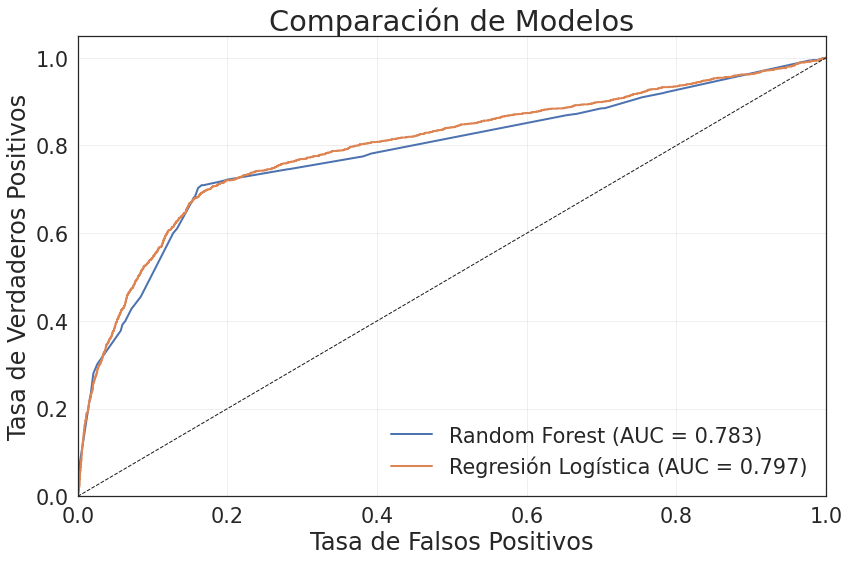

In [26]:
plt.figure(figsize=(12, 8))

# Usar los tamaños de fuente especificados
base_size = 16
title_fontsize = base_size * 1.8  # 24pt
label_fontsize = base_size * 1.5  # 19.2pt  
tick_fontsize = base_size * 1.3   # 16pt
legend_fontsize = base_size * 1.3 # 16pt

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_pred_proba)
rf_auc = roc_auc_score(y_test, rf_pred_proba)
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.3f})', linewidth=2)

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_pred_proba)
lr_auc = roc_auc_score(y_test, lr_pred_proba)
plt.plot(lr_fpr, lr_tpr, label=f'Regresión Logística (AUC = {lr_auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos', fontsize=label_fontsize)
plt.ylabel('Tasa de Verdaderos Positivos', fontsize=label_fontsize)
plt.title('Comparación de Modelos', fontsize=title_fontsize, )
plt.legend(loc="lower right", fontsize=legend_fontsize)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=tick_fontsize)
plt.tight_layout()
plt.show()

<div style="page-break-before: always; margin-top: 0;"></div>

Las curvas ROC revelan que ambos modelos superan significativamente la línea base aleatoria (diagonal), demostrando su capacidad para distinguir entre clientes que suscriben y no suscriben depósitos. El Random Forest alcanza un AUC de 0.7832, mientras que la Regresión Logística registra un AUC ligeramente superior de 0.7972. Esto indica que, aunque ambos modelos son efectivos, la Regresión Logística tiene una ventaja marginal en la discriminación global entre clases, especialmente en rangos intermedios de probabilidad. La curva de la Regresión Logística muestra una pendiente más pronunciada inicialmente, lo que sugiere mayor sensibilidad para identificar verdaderos positivos con bajos falsos positivos en umbrales bajos, mientras que el Random Forest mantiene un equilibrio más estable entre TVP y TFP en rangos extremos.

A pesar de la ligera ventaja en AUC de la Regresión Logística, la elección del modelo debe considerar el objetivo específico de la campaña. Si el enfoque es maximizar el recall (como se priorizó durante el ajuste de hiperparámetros), el Random Forest podría ser preferible, ya que su curva ROC muestra un TPR más alto en umbrales altos (asociados a mayores probabilidades de conversión), lo que se alinea con la necesidad de capturar la mayor cantidad de clientes potenciales, incluso a costa de más falsos positivos. Por otro lado, la Regresión Logística, con su mayor AUC, es más adecuada si se busca un equilibrio entre discriminación y simplicidad, especialmente en escenarios donde la interpretabilidad de coeficientes es crítica para la toma de decisiones. Ambos modelos, sin embargo, validan la robustez del enfoque predictivo, con AUCs que superan ampliamente el umbral de 0.7, lo que refuerza su utilidad para guiar estrategias de marketing focalizadas.

<a id='importancia-variables'></a>
<div style="page-break-before: always; margin-top: 0;">
<h2>Importancia de las variables</h2>
</div>

<a id='importancia-random-forest'></a>

### Random forest


In [27]:
cat_features = rf_grid.best_estimator_.named_steps['preprocessor']\
                .named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)

feature_names = numerical_cols + list(cat_features)

rf_importance = rf_grid.best_estimator_.named_steps['classifier'].feature_importances_
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_importance
}).sort_values('Importance', ascending=False).head(15)

display(feature_importance.style
        .hide(axis='index')
        .set_properties(**{'text-align': 'center', 'white-space': 'normal'})
        .set_table_styles([
            {'selector': 'td', 'props': [('text-align', 'center'), ('white-space', 'normal'), ('word-wrap', 'break-word')]},
            {'selector': 'th', 'props': [('text-align', 'center')]},
            {'selector': 'table', 'props': [('table-layout', 'auto'), ('width', '100%')]},
            {'selector': 'th.row_heading', 'props': [('text-align', 'center')]}
        ])
        .format({'Importance': '{:.4f}'})
        )

Feature,Importance
euribor3m,0.3001
emp.var.rate,0.2856
nr.employed,0.2252
cons.conf.idx,0.0727
pdays,0.0426
poutcome_success,0.0415
education_university.degree,0.0089
cons.price.idx,0.0054
poutcome_nonexistent,0.0047
campaign,0.0036


<a id='importancia-regresion-logistica'></a>
<div style="page-break-before: always; margin-top: 0;">
<h3>Regresión logística</h3>
</div>

In [28]:
lr_coef = lr_grid.best_estimator_.named_steps['classifier'].coef_[0]
lr_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coeficiente': lr_coef
}).sort_values('Coeficiente', key=abs, ascending=False).head(15)

display(lr_importance.style
        .hide(axis='index')
        .set_properties(**{'text-align': 'center', 'white-space': 'normal'})
        .set_table_styles([
            {'selector': 'td', 'props': [('text-align', 'center'), ('white-space', 'normal'), ('word-wrap', 'break-word')]},
            {'selector': 'th', 'props': [('text-align', 'center')]},
            {'selector': 'table', 'props': [('table-layout', 'auto'), ('width', '100%')]},
            {'selector': 'th.row_heading', 'props': [('text-align', 'center')]}
        ])
        .format({'Coeficiente': '{:.4f}'})
        )

Feature,Coeficiente
emp.var.rate,-1.3613
contact_telephone,-1.0885
euribor3m,0.8396
cons.price.idx,0.7366
nr.employed,-0.5392
poutcome_nonexistent,0.5064
job_retired,0.4805
job_student,0.4572
poutcome_success,0.3287
default_unknown,-0.2604


<div style="page-break-before: always; margin-top: 0;"></div>

**Random Forest** destaca variables macroeconómicas como las más influyentes: euribor3m (0.3001), emp.var.rate (0.2856) y nr.employed (0.2252). Estas reflejan el impacto del entorno económico en la decisión del cliente, con tasas de interés bajas y altos niveles de empleo asociados a mayores conversiones. Variables secundarias incluyen cons.conf.idx (0.0727) y pdays (0.0426), mientras que factores demográficos como education_university.degree (0.0089) tienen menor peso. La ausencia de variables de contacto en las primeras posiciones sugiere que el modelo prioriza indicadores externos sobre características operativas.

**Regresión Logística** revela patrones distintos: emp.var.rate (-1.3613) y contact_telephone (-1.0885) son los coeficientes más negativos, indicando que un mayor número de contactos telefónicos y una baja tasa de variación del empleo reducen la probabilidad de conversión. En contraste, euribor3m (0.8396) y cons.price.idx (0.7366) muestran relación positiva, alineándose con el análisis de Random Forest. Destaca poutcome_nonexistent (0.5064), que refuerza la importancia del historial previo: clientes sin interacción previa tienen menor probabilidad de suscribir. La dirección de los coeficientes permite interpretar estrategias, como priorizar contactos celulares (coeficiente positivo implícito en la ausencia de teléfono fijo).

Ambos modelos coinciden en la relevancia de euribor3m y emp.var.rate, validando su rol como predictores robustos. Sin embargo, Random Forest enfatiza el impacto colectivo de variables económicas, mientras Regresión Logística destaca la importancia de factores operativos como el canal de contacto. Esta divergencia refleja diferencias metodológicas: Random Forest captura interacciones no lineales entre variables, mientras la Regresión Logística ofrece una interpretación lineal directa. Para la campaña, esto implica que:  

**Variables económicas** son críticas en ambos enfoques, reforzando la necesidad de ajustar estrategias según el contexto macroeconómico.  
**El canal de contacto** (teléfono vs. celular) emerge como factor ajustable en la Regresión Logística, sugiriendo oportunidades para optimizar la logística de la campaña.  
**El historial previo** (poutcome) es consistente en ambos modelos, subrayando la importancia de segmentar clientes según su respuesta a campañas anteriores.  

Estos hallazgos respaldan un enfoque híbrido: usar Random Forest para identificar variables macroeconómicas clave y Regresión Logística para refinar tácticas operativas, maximizando así la efectividad de la campaña.

<a id='conclusiones'></a>
<div style="page-break-before: always; margin-top: 0;">
<h1>Conclusiones Finales</h1>
</div>

## Resumen del Análisis

Este estudio analizó una campaña de marketing bancario para depósitos a plazo, identificando patrones clave en el comportamiento de los clientes y desarrollando modelos predictivos para optimizar futuras campañas. Los hallazgos principales incluyen:

1. **Perfil del cliente con alta conversión**: Jubilados (25%), estudiantes (20%) y universitarios (14.2%) muestran tasas excepcionales de suscripción.
2. **Factores económicos clave**: Bajas tasas de interés (euribor3m ~1%) y alto empleo (~5,100 empleados) aumentan significativamente la probabilidad de conversión.
3. **Patrones temporales críticos**: Marzo, septiembre y diciembre registran tasas de conversión 4-5 veces superiores al promedio (44-50%), mientras los jueves son el día más efectivo (12.1%).
4. **Variables operativas**: Contactos celulares y duraciones superiores a 200 segundos duplican la probabilidad de éxito.

## Recomendaciones Estratégicas

- **Segmentación de Clientes**
    - **Priorizar**: Jubilados, estudiantes y titulados universitarios
    - **Evitar**: Jóvenes <30 años en empleos inestables o con préstamos personales

### Optimización Temporal
- **Concentrar recursos** en marzo, septiembre y diciembre
- **Maximizar contactos los jueves** (día de mayor efectividad)
- **Limitar campañas** en mayo-julio (baja conversión a pesar de alto volumen)

### Gestión de Contacto
- **Buscar interacciones >200 segundos** (3x más probabilidad de éxito)
- **Limitar intentos** por cliente (3-5 contactos por campaña)
- **Priorizar canal celular** sobre teléfono fijo

<div style="page-break-before: always; margin-top: 0;"></div>

### Implementación Modelos
1. **Random Forest para identificación temprana**: Usar en fases iniciales para capturar clientes de alta probabilidad
2. **Regresión Logística para optimización continua**: Emplear en etapas avanzadas por su estabilidad en muestras grandes
3. **Variables económicas como termómetro**: Monitorear euribor3m y nr.employed para ajustar estrategias

## Limitaciones y Trabajo Futuro
- **Desafíos de datos**: 20.9% valores desconocidos en morosidad (default) y 4.2% en educación requieren estrategias de imputación avanzada
- **Validación en campo**: Implementar pruebas A/B con los segmentos identificados
- **Optimización de costos**: Desarrollar modelo de costo-beneficio para minimizar falsos positivos
- **Análisis de ciclo económico**: Profundizar en impacto de recesiones/expansiones en tasas de conversión

**Impacto esperado**: La implementación de estas recomendaciones podría incrementar la tasa de conversión y optimizar el costo por adquisición, maximizando el ROI de futuras campañas.
